# Inside the Neural Network: The Training Loop

In the last lesson, we built an MLP that learned to classify Titanic passengers. We wrote code like this:

```python
mlp = MLP(n_features=4, n_hidden=16)
optimizer = optim.Adam(mlp.parameters(), lr=0.01)

for epoch in range(200):
    y_pred = mlp(X_train_t)       # Forward pass
    loss = loss_fn(y_pred, y_train_t)
    optimizer.zero_grad()
    loss.backward()                # Backward pass
    optimizer.step()               # Update weights
```

It worked. But what's actually happening inside? What does `mlp(X_train_t)` compute? What does `loss.backward()` do? What are these "weights" being updated?

This lesson opens the black box. By the end, you'll understand:
- What weights are and how they're initialized
- The **forward pass**: how data flows through the network (main focus)
- What the **loss** measures
- The **backward pass**: how gradients tell us which weights to blame
- How **weight updates** improve the model

We won't dive into the calculus of backpropagation — that's not necessary to use neural networks effectively. Instead, we'll build intuition for what each piece does.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from pathlib import Path
DATA_PATH = Path("../../../../data")

np.random.seed(42)
torch.manual_seed(42)

print(f"PyTorch version: {torch.__version__}")
print("Ready!")

In [2]:
# === VISUALIZATION HELPERS ===
# Table-based visualizations for understanding neural networks

import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, Circle, FancyArrowPatch, Rectangle
from matplotlib.table import Table
import matplotlib.patheffects as path_effects

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def show_data_table(data, row_labels, col_labels, title="", highlight_row=None, figsize=(10, 4), decimals=2):
    """
    Display data as a clean table with optional row highlighting.
    
    data: 2D array
    row_labels: list of row names
    col_labels: list of column names (shown on top)
    highlight_row: index of row to highlight (or None)
    """
    n_rows, n_cols = data.shape
    
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis('off')
    
    # Create table
    table = ax.table(
        cellText=[[f'{data[i,j]:.{decimals}f}' for j in range(n_cols)] for i in range(n_rows)],
        rowLabels=row_labels,
        colLabels=col_labels,
        cellLoc='center',
        rowLoc='center',
        loc='center'
    )
    
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.2, 1.8)
    
    # Style header row
    for j in range(n_cols):
        table[(0, j)].set_facecolor('#3498db')
        table[(0, j)].set_text_props(color='white', fontweight='bold')
    
    # Style row labels
    for i in range(n_rows):
        table[(i+1, -1)].set_facecolor('#ecf0f1')
        table[(i+1, -1)].set_text_props(fontweight='bold')
    
    # Highlight specific row if requested
    if highlight_row is not None:
        for j in range(n_cols):
            table[(highlight_row + 1, j)].set_facecolor('#f1c40f')
            table[(highlight_row + 1, j)].set_text_props(fontweight='bold')
        table[(highlight_row + 1, -1)].set_facecolor('#f39c12')
    
    if title:
        ax.set_title(title, fontsize=13, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()

def show_extracted_row(data, row_idx, col_labels, row_label, title=""):
    """Show a single extracted row as a horizontal table."""
    row = data[row_idx:row_idx+1]  # Keep 2D shape
    
    fig, ax = plt.subplots(figsize=(10, 1.5))
    ax.axis('off')
    
    table = ax.table(
        cellText=[[f'{row[0,j]:.2f}' for j in range(len(col_labels))]],
        colLabels=col_labels,
        rowLabels=[row_label],
        cellLoc='center',
        loc='center'
    )
    
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.3, 2.0)
    
    # Style header
    for j in range(len(col_labels)):
        table[(0, j)].set_facecolor('#3498db')
        table[(0, j)].set_text_props(color='white', fontweight='bold')
    
    # Style data row
    for j in range(len(col_labels)):
        table[(1, j)].set_facecolor('#f1c40f')
        table[(1, j)].set_text_props(fontweight='bold')
    
    table[(1, -1)].set_facecolor('#f39c12')
    table[(1, -1)].set_text_props(fontweight='bold', color='white')
    
    if title:
        ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    
    plt.tight_layout()
    plt.show()

def show_weight_table(weights, feature_labels, neuron_labels, title="Weight Matrix", 
                      highlight_neuron=None, show_as_rows=True):
    """
    Display weight matrix as a table.
    
    weights: 2D array where each ROW is one neuron's weights (for display clarity)
    feature_labels: column headers (input features)
    neuron_labels: row labels (neurons)
    highlight_neuron: index of neuron row to highlight
    show_as_rows: if True, neurons are rows; if False, neurons are columns
    """
    if not show_as_rows:
        weights = weights.T
        neuron_labels, feature_labels = feature_labels, neuron_labels
    
    n_neurons, n_features = weights.shape
    
    fig, ax = plt.subplots(figsize=(12, 2 + n_neurons * 0.5))
    ax.axis('off')
    
    # Create cell text with colors based on value
    cell_text = [[f'{weights[i,j]:+.2f}' for j in range(n_features)] for i in range(n_neurons)]
    
    table = ax.table(
        cellText=cell_text,
        rowLabels=neuron_labels,
        colLabels=feature_labels,
        cellLoc='center',
        loc='center'
    )
    
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.2, 1.8)
    
    # Style header row
    for j in range(n_features):
        table[(0, j)].set_facecolor('#3498db')
        table[(0, j)].set_text_props(color='white', fontweight='bold')
    
    # Style cells based on weight value and row labels
    vmax = np.abs(weights).max()
    for i in range(n_neurons):
        # Row label
        table[(i+1, -1)].set_facecolor('#9b59b6')
        table[(i+1, -1)].set_text_props(color='white', fontweight='bold')
        
        # Data cells - color by value
        for j in range(n_features):
            val = weights[i, j]
            if val > 0:
                intensity = min(val / vmax, 1.0)
                table[(i+1, j)].set_facecolor((0.2, 0.6 + 0.4*intensity, 0.2, 0.3 + 0.5*intensity))
            else:
                intensity = min(abs(val) / vmax, 1.0)
                table[(i+1, j)].set_facecolor((0.9, 0.2, 0.2, 0.3 + 0.5*intensity))
    
    # Highlight specific neuron if requested
    if highlight_neuron is not None:
        for j in range(n_features):
            table[(highlight_neuron + 1, j)].set_facecolor('#f1c40f')
            table[(highlight_neuron + 1, j)].set_text_props(fontweight='bold')
        table[(highlight_neuron + 1, -1)].set_facecolor('#f39c12')
    
    ax.set_title(title, fontsize=13, fontweight='bold', pad=20)
    
    # Add legend for colors
    ax.text(0.5, -0.05, 'Green = positive weight | Red = negative weight', 
            transform=ax.transAxes, ha='center', fontsize=10, style='italic')
    
    plt.tight_layout()
    plt.show()

def show_neuron_computation(input_row, neuron_weights, bias, input_labels, neuron_name="Neuron 0"):
    """
    Show step-by-step computation for ONE neuron processing ONE input.
    Uses tables to show the multiplication clearly.
    """
    products = input_row * neuron_weights
    weighted_sum = products.sum()
    z = weighted_sum + bias
    activation = max(0, z)
    
    n_features = len(input_row)
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 6), gridspec_kw={'height_ratios': [1, 1.2]})
    
    # Top: The multiplication table
    ax = axes[0]
    ax.axis('off')
    
    # Build the table: 3 rows (input, weights, product) x n_features columns
    cell_text = [
        [f'{input_row[j]:.2f}' for j in range(n_features)],
        [f'{neuron_weights[j]:+.2f}' for j in range(n_features)],
        [f'{products[j]:+.3f}' for j in range(n_features)]
    ]
    row_labels = ['Input (x)', f'{neuron_name} weights (w)', 'Product (x × w)']
    
    table = ax.table(
        cellText=cell_text,
        rowLabels=row_labels,
        colLabels=input_labels,
        cellLoc='center',
        loc='center'
    )
    
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.2, 2.0)
    
    # Style header
    for j in range(n_features):
        table[(0, j)].set_facecolor('#3498db')
        table[(0, j)].set_text_props(color='white', fontweight='bold')
    
    # Style rows
    colors = ['#f1c40f', '#9b59b6', '#2ecc71']
    for i, color in enumerate(colors):
        table[(i+1, -1)].set_facecolor(color)
        table[(i+1, -1)].set_text_props(color='white', fontweight='bold')
        for j in range(n_features):
            table[(i+1, j)].set_facecolor(color if i < 2 else None)
            if i < 2:
                table[(i+1, j)].set_text_props(fontweight='bold')
            if i == 2:  # Products row - color by sign
                val = products[j]
                if val >= 0:
                    table[(i+1, j)].set_facecolor('#2ecc71')
                else:
                    table[(i+1, j)].set_facecolor('#e74c3c')
                table[(i+1, j)].set_text_props(color='white', fontweight='bold')
    
    ax.set_title(f'{neuron_name}: Element-wise Multiplication', fontsize=12, fontweight='bold', pad=10)
    
    # Bottom: The sum and activation
    ax = axes[1]
    ax.axis('off')
    
    # Show the equation
    product_str = ' + '.join([f'({products[j]:+.3f})' for j in range(n_features)])
    
    text = f"""
    Step 1: Multiply each input by its weight (shown above)
    
    Step 2: Sum all products
            {product_str}
            = {weighted_sum:+.4f}
    
    Step 3: Add bias
            {weighted_sum:+.4f} + ({bias:+.4f}) = {z:+.4f}
    
    Step 4: Apply ReLU (max(0, z))
            ReLU({z:+.4f}) = {activation:.4f}
    """
    
    ax.text(0.05, 0.95, text, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='#ecf0f1', alpha=0.8))
    
    # Final result box
    result_color = '#2ecc71' if activation > 0 else '#95a5a6'
    ax.text(0.75, 0.5, f'{neuron_name}\nOutput: {activation:.4f}', 
            transform=ax.transAxes, fontsize=14, fontweight='bold',
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.5', facecolor=result_color, edgecolor='black', linewidth=2))
    
    plt.tight_layout()
    plt.show()
    
    return activation

def show_all_neurons_computation(input_row, weight_matrix, biases, input_labels, neuron_labels):
    """
    Show computation for ALL neurons at once, emphasizing parallel structure.
    weight_matrix: shape (n_neurons, n_features) - each ROW is one neuron
    """
    n_neurons, n_features = weight_matrix.shape
    
    # Compute all outputs
    products = input_row * weight_matrix  # Broadcasting: (n_neurons, n_features)
    weighted_sums = products.sum(axis=1)
    z_values = weighted_sums + biases
    activations = np.maximum(0, z_values)
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 3 + n_neurons * 0.4))
    
    # Left: Input row (repeated for visual clarity)
    ax = axes[0]
    ax.axis('off')
    
    cell_text = [[f'{input_row[j]:.2f}' for j in range(n_features)]]
    table = ax.table(
        cellText=cell_text,
        colLabels=input_labels,
        rowLabels=['Input'],
        cellLoc='center',
        loc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.2, 2.0)
    
    for j in range(n_features):
        table[(0, j)].set_facecolor('#3498db')
        table[(0, j)].set_text_props(color='white', fontweight='bold')
        table[(1, j)].set_facecolor('#f1c40f')
        table[(1, j)].set_text_props(fontweight='bold')
    table[(1, -1)].set_facecolor('#f39c12')
    table[(1, -1)].set_text_props(color='white', fontweight='bold')
    
    ax.set_title('Same input goes to ALL neurons', fontsize=11, fontweight='bold')
    
    # Middle: Weight matrix with products
    ax = axes[1]
    ax.axis('off')
    
    # Show products for each neuron
    cell_text = [[f'{products[i,j]:+.2f}' for j in range(n_features)] + [f'{weighted_sums[i]:+.2f}'] 
                 for i in range(n_neurons)]
    
    table = ax.table(
        cellText=cell_text,
        colLabels=input_labels + ['Sum'],
        rowLabels=neuron_labels,
        cellLoc='center',
        loc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.1, 1.6)
    
    # Style header
    for j in range(n_features + 1):
        table[(0, j)].set_facecolor('#3498db')
        table[(0, j)].set_text_props(color='white', fontweight='bold')
    
    # Style rows
    for i in range(n_neurons):
        table[(i+1, -1)].set_facecolor('#9b59b6')
        table[(i+1, -1)].set_text_props(color='white', fontweight='bold')
        # Color products by sign
        for j in range(n_features):
            val = products[i, j]
            table[(i+1, j)].set_facecolor('#d5f5e3' if val >= 0 else '#fadbd8')
        # Sum column
        table[(i+1, n_features)].set_facecolor('#aed6f1')
        table[(i+1, n_features)].set_text_props(fontweight='bold')
    
    ax.set_title('Products (input × weights) for each neuron', fontsize=11, fontweight='bold')
    
    # Right: Final outputs
    ax = axes[2]
    ax.axis('off')
    
    cell_text = [[f'{weighted_sums[i]:+.2f}', f'{biases[i]:+.2f}', f'{z_values[i]:+.2f}', f'{activations[i]:.2f}'] 
                 for i in range(n_neurons)]
    
    table = ax.table(
        cellText=cell_text,
        colLabels=['Sum', '+Bias', '=z', 'ReLU(z)'],
        rowLabels=neuron_labels,
        cellLoc='center',
        loc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.1, 1.6)
    
    # Style header
    for j in range(4):
        table[(0, j)].set_facecolor('#3498db')
        table[(0, j)].set_text_props(color='white', fontweight='bold')
    
    # Style rows
    for i in range(n_neurons):
        table[(i+1, -1)].set_facecolor('#9b59b6')
        table[(i+1, -1)].set_text_props(color='white', fontweight='bold')
        # ReLU output column - green if active, gray if zero
        if activations[i] > 0:
            table[(i+1, 3)].set_facecolor('#2ecc71')
            table[(i+1, 3)].set_text_props(color='white', fontweight='bold')
        else:
            table[(i+1, 3)].set_facecolor('#bdc3c7')
    
    ax.set_title('Bias, z, and ReLU output', fontsize=11, fontweight='bold')
    
    plt.suptitle('All Neurons Process the Same Input in Parallel', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return activations

def show_matrix_multiply_step(X, W, result, sample_labels, feature_labels, neuron_labels, 
                              highlight_sample=None, highlight_neuron=None):
    """
    Show the matrix multiplication X @ W with optional highlighting.
    This shows how multiple samples get processed by multiple neurons.
    """
    n_samples, n_features = X.shape
    n_neurons = W.shape[0]  # W has neurons as ROWS for display
    
    fig, axes = plt.subplots(1, 5, figsize=(18, max(3, n_samples * 0.5 + 1)),
                             gridspec_kw={'width_ratios': [3, 0.5, 3, 0.5, 3]})
    
    # Input matrix
    ax = axes[0]
    ax.axis('off')
    cell_text = [[f'{X[i,j]:.2f}' for j in range(n_features)] for i in range(n_samples)]
    table = ax.table(
        cellText=cell_text,
        colLabels=feature_labels,
        rowLabels=sample_labels,
        cellLoc='center',
        loc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.1, 1.5)
    
    for j in range(n_features):
        table[(0, j)].set_facecolor('#3498db')
        table[(0, j)].set_text_props(color='white', fontweight='bold')
    for i in range(n_samples):
        table[(i+1, -1)].set_facecolor('#ecf0f1')
        if highlight_sample == i:
            for j in range(n_features):
                table[(i+1, j)].set_facecolor('#f1c40f')
            table[(i+1, -1)].set_facecolor('#f39c12')
    
    ax.set_title(f'Input X\n({n_samples} × {n_features})', fontsize=11, fontweight='bold')
    
    # @ symbol
    axes[1].axis('off')
    axes[1].text(0.5, 0.5, '@', fontsize=24, ha='center', va='center', fontweight='bold')
    
    # Weight matrix (neurons as rows)
    ax = axes[2]
    ax.axis('off')
    cell_text = [[f'{W[i,j]:+.2f}' for j in range(n_features)] for i in range(n_neurons)]
    table = ax.table(
        cellText=cell_text,
        colLabels=feature_labels,
        rowLabels=neuron_labels,
        cellLoc='center',
        loc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.1, 1.5)
    
    for j in range(n_features):
        table[(0, j)].set_facecolor('#3498db')
        table[(0, j)].set_text_props(color='white', fontweight='bold')
    for i in range(n_neurons):
        table[(i+1, -1)].set_facecolor('#9b59b6')
        table[(i+1, -1)].set_text_props(color='white', fontweight='bold')
        if highlight_neuron == i:
            for j in range(n_features):
                table[(i+1, j)].set_facecolor('#e8daef')
            table[(i+1, -1)].set_facecolor('#8e44ad')
    
    ax.set_title(f'Weights W\n({n_neurons} × {n_features})', fontsize=11, fontweight='bold')
    
    # = symbol
    axes[3].axis('off')
    axes[3].text(0.5, 0.5, '=', fontsize=24, ha='center', va='center', fontweight='bold')
    
    # Result matrix
    ax = axes[4]
    ax.axis('off')
    cell_text = [[f'{result[i,j]:.2f}' for j in range(n_neurons)] for i in range(n_samples)]
    table = ax.table(
        cellText=cell_text,
        colLabels=neuron_labels,
        rowLabels=sample_labels,
        cellLoc='center',
        loc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.1, 1.5)
    
    for j in range(n_neurons):
        table[(0, j)].set_facecolor('#9b59b6')
        table[(0, j)].set_text_props(color='white', fontweight='bold')
    for i in range(n_samples):
        table[(i+1, -1)].set_facecolor('#ecf0f1')
        if highlight_sample == i:
            table[(i+1, -1)].set_facecolor('#f39c12')
        for j in range(n_neurons):
            # Color based on value
            val = result[i, j]
            if val > 0:
                table[(i+1, j)].set_facecolor('#d5f5e3')
            else:
                table[(i+1, j)].set_facecolor('#fadbd8')
            if highlight_sample == i and highlight_neuron == j:
                table[(i+1, j)].set_facecolor('#f1c40f')
                table[(i+1, j)].set_text_props(fontweight='bold')
    
    ax.set_title(f'Result\n({n_samples} × {n_neurons})', fontsize=11, fontweight='bold')
    
    plt.suptitle('Matrix Multiplication: Each cell is a dot product', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

def plot_relu_comparison(before, after, labels):
    """Show before/after ReLU as a simple comparison table."""
    n = len(before)
    
    fig, ax = plt.subplots(figsize=(12, 2))
    ax.axis('off')
    
    cell_text = [
        [f'{before[j]:+.2f}' for j in range(n)],
        [f'{after[j]:.2f}' for j in range(n)]
    ]
    
    table = ax.table(
        cellText=cell_text,
        colLabels=labels,
        rowLabels=['Before ReLU (z)', 'After ReLU'],
        cellLoc='center',
        loc='center'
    )
    
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.2, 2.0)
    
    # Style header
    for j in range(n):
        table[(0, j)].set_facecolor('#3498db')
        table[(0, j)].set_text_props(color='white', fontweight='bold')
    
    # Style rows
    for j in range(n):
        # Before ReLU - red if negative
        if before[j] < 0:
            table[(1, j)].set_facecolor('#e74c3c')
            table[(1, j)].set_text_props(color='white', fontweight='bold')
        else:
            table[(1, j)].set_facecolor('#d5f5e3')
        
        # After ReLU - gray if zero, green if positive
        if after[j] == 0:
            table[(2, j)].set_facecolor('#bdc3c7')
        else:
            table[(2, j)].set_facecolor('#2ecc71')
            table[(2, j)].set_text_props(color='white', fontweight='bold')
    
    # Row labels
    table[(1, -1)].set_facecolor('#f39c12')
    table[(1, -1)].set_text_props(color='white', fontweight='bold')
    table[(2, -1)].set_facecolor('#27ae60')
    table[(2, -1)].set_text_props(color='white', fontweight='bold')
    
    ax.set_title('ReLU: Negative values → 0, Positive values → unchanged', fontsize=12, fontweight='bold', pad=10)
    plt.tight_layout()
    plt.show()

def plot_training_progress(losses, accuracies=None):
    """Plot training loss and optionally accuracy."""
    if accuracies:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        axes[0].plot(losses, color='#3498db', linewidth=2)
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Training Loss', fontweight='bold')
        axes[0].grid(True, alpha=0.3)
        
        axes[1].plot(accuracies, color='#2ecc71', linewidth=2)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy')
        axes[1].set_title('Training Accuracy', fontweight='bold')
        axes[1].grid(True, alpha=0.3)
    else:
        plt.figure(figsize=(10, 4))
        plt.plot(losses, color='#3498db', linewidth=2)
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training Loss', fontweight='bold')
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_gradient_intuition():
    """Visualize the concept of gradients."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    w = np.linspace(-3, 3, 100)
    loss = (w - 1)**2 + 0.5
    axes[0].plot(w, loss, 'b-', linewidth=2)
    
    w_current = -1.5
    loss_current = (w_current - 1)**2 + 0.5
    gradient = 2 * (w_current - 1)
    
    axes[0].scatter([w_current], [loss_current], color='red', s=100, zorder=5)
    axes[0].annotate(f'Current position\nGradient = {gradient:.1f}',
                     xy=(w_current, loss_current), xytext=(w_current-0.5, loss_current+2),
                     fontsize=10, arrowprops=dict(arrowstyle='->', color='red'))
    
    axes[0].annotate('', xy=(w_current + 1.2, loss_current - 1.5), xytext=(w_current, loss_current),
                     arrowprops=dict(arrowstyle='->', color='green', lw=2))
    axes[0].text(w_current + 0.3, loss_current - 0.5, 'Move opposite\nto gradient', fontsize=9, color='green')
    
    axes[0].scatter([1], [0.5], color='green', s=100, marker='*', zorder=5)
    axes[0].text(1.1, 0.8, 'Minimum', fontsize=10, color='green')
    
    axes[0].set_xlabel('Weight value')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Gradient Descent: Go Downhill', fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    # Right side explanation
    axes[1].axis('off')
    text = """
    What the Gradient Tells Us:
    
    • Negative gradient → increase weight to reduce loss
    • Positive gradient → decrease weight to reduce loss
    • Large gradient → big effect on loss
    • Small gradient → small effect on loss
    
    Update Rule:
    
        weight_new = weight_old - learning_rate × gradient
    
    We subtract because we want to go OPPOSITE to the gradient
    (gradient points uphill, we want to go downhill)
    """
    axes[1].text(0.1, 0.9, text, transform=axes[1].transAxes, fontsize=12,
                 verticalalignment='top', fontfamily='monospace',
                 bbox=dict(boxstyle='round', facecolor='#ecf0f1', alpha=0.8))
    
    plt.tight_layout()
    plt.show()



def draw_neural_network(layer_sizes, layer_names=None, figsize=(12, 5), title="Neural Network Architecture"):
    """
    Draw a neural network with circles (neurons) connected by lines (weights).
    
    layer_sizes: list of integers, e.g. [4, 5, 1] for 4 inputs, 5 hidden, 1 output
    layer_names: list of strings for layer labels
    """
    if layer_names is None:
        layer_names = ['Input\nLayer', 'Hidden\nLayer', 'Output\nLayer']
    
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis('off')
    
    n_layers = len(layer_sizes)
    max_neurons = max(layer_sizes)
    
    # Colors for each layer
    colors = ['#3498db', '#9b59b6', '#2ecc71']
    
    # Calculate positions
    layer_x = np.linspace(0.15, 0.85, n_layers)
    
    neuron_positions = []
    
    for layer_idx, n_neurons in enumerate(layer_sizes):
        # Vertically center neurons
        if n_neurons == 1:
            y_positions = [0.5]
        else:
            y_positions = np.linspace(0.1, 0.9, n_neurons)
        
        layer_positions = [(layer_x[layer_idx], y) for y in y_positions]
        neuron_positions.append(layer_positions)
        
        # Draw neurons
        for i, (x, y) in enumerate(layer_positions):
            circle = plt.Circle((x, y), 0.035, color=colors[layer_idx % len(colors)], 
                               ec='black', linewidth=2, zorder=3)
            ax.add_patch(circle)
            
            # Add neuron labels for input layer
            if layer_idx == 0 and i < 4:
                labels = ['x₁', 'x₂', 'x₃', 'x₄']
                ax.text(x, y, labels[i] if i < len(labels) else f'x_{i+1}', 
                       ha='center', va='center', fontsize=10, fontweight='bold', color='white', zorder=4)
            elif layer_idx == n_layers - 1:
                ax.text(x, y, 'ŷ', ha='center', va='center', fontsize=12, fontweight='bold', color='white', zorder=4)
    
    # Draw connections (weights)
    for layer_idx in range(n_layers - 1):
        for i, (x1, y1) in enumerate(neuron_positions[layer_idx]):
            for j, (x2, y2) in enumerate(neuron_positions[layer_idx + 1]):
                # Draw line with some transparency
                ax.plot([x1, x2], [y1, y2], 'gray', alpha=0.3, linewidth=0.8, zorder=1)
    
    # Add layer names
    for layer_idx, name in enumerate(layer_names):
        ax.text(layer_x[layer_idx], -0.05, name, ha='center', va='top', fontsize=12, fontweight='bold')
    
    # Add annotations
    ax.annotate('', xy=(0.35, 0.5), xytext=(0.25, 0.5),
                arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=2))
    ax.text(0.30, 0.55, 'weights', ha='center', fontsize=10, color='#e74c3c', style='italic')
    
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.15, 1)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()

def draw_single_neuron_detailed(figsize=(12, 4)):
    """
    Draw a detailed single neuron showing inputs, weights, sum, activation.
    """
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis('off')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    
    # Input circles on the left
    input_labels = ['x₁', 'x₂', 'x₃', 'x₄']
    input_y = [0.8, 0.6, 0.4, 0.2]
    
    for i, (label, y) in enumerate(zip(input_labels, input_y)):
        # Input circle
        circle = plt.Circle((0.1, y), 0.04, color='#3498db', ec='black', linewidth=2, zorder=3)
        ax.add_patch(circle)
        ax.text(0.1, y, label, ha='center', va='center', fontsize=11, fontweight='bold', color='white', zorder=4)
        
        # Arrow with weight label
        ax.annotate('', xy=(0.35, 0.5), xytext=(0.14, y),
                   arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=1.5, 
                                  connectionstyle='arc3,rad=0'))
        
        # Weight label
        mid_x = 0.22
        mid_y = (y + 0.5) / 2
        ax.text(mid_x, mid_y, f'w{i+1}', fontsize=9, color='#e74c3c', fontweight='bold')
    
    # Main neuron body (sum)
    circle = plt.Circle((0.42, 0.5), 0.07, color='#f39c12', ec='black', linewidth=2, zorder=3)
    ax.add_patch(circle)
    ax.text(0.42, 0.5, 'Σ', ha='center', va='center', fontsize=18, fontweight='bold', zorder=4)
    
    # Bias annotation
    ax.annotate('', xy=(0.42, 0.43), xytext=(0.42, 0.25),
               arrowprops=dict(arrowstyle='->', color='#9b59b6', lw=2))
    ax.text(0.42, 0.20, '+b (bias)', ha='center', fontsize=10, color='#9b59b6', fontweight='bold')
    
    # Arrow to activation
    ax.annotate('', xy=(0.58, 0.5), xytext=(0.49, 0.5),
               arrowprops=dict(arrowstyle='->', color='black', lw=2))
    ax.text(0.535, 0.55, 'z', ha='center', fontsize=10, fontweight='bold')
    
    # Activation function box
    rect = plt.Rectangle((0.58, 0.42), 0.12, 0.16, fill=True, 
                         facecolor='#2ecc71', edgecolor='black', linewidth=2, zorder=3)
    ax.add_patch(rect)
    ax.text(0.64, 0.5, 'f(z)', ha='center', va='center', fontsize=12, fontweight='bold', color='white', zorder=4)
    ax.text(0.64, 0.35, 'activation', ha='center', fontsize=9, style='italic')
    
    # Output arrow
    ax.annotate('', xy=(0.85, 0.5), xytext=(0.70, 0.5),
               arrowprops=dict(arrowstyle='->', color='black', lw=2))
    
    # Output circle
    circle = plt.Circle((0.88, 0.5), 0.04, color='#2ecc71', ec='black', linewidth=2, zorder=3)
    ax.add_patch(circle)
    ax.text(0.88, 0.5, 'a', ha='center', va='center', fontsize=11, fontweight='bold', color='white', zorder=4)
    ax.text(0.88, 0.40, 'output', ha='center', fontsize=9, style='italic')
    
    # Title and formula
    ax.set_title('Single Neuron: The Basic Building Block', fontsize=14, fontweight='bold', pad=10)
    
    # Formula at bottom
    ax.text(0.5, 0.05, 'z = w₁x₁ + w₂x₂ + w₃x₃ + w₄x₄ + b      then      a = f(z)', 
            ha='center', fontsize=11, fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='#ecf0f1', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

print("Visualization helpers loaded!")


def show_forward_pass_detailed(input_row, weight_matrix, biases, feature_labels, neuron_labels):
    """
    Full view: Input × Weight Matrix → Products → Sum → + Bias → ReLU → Output
    """
    n_neurons, n_features = weight_matrix.shape
    
    fig, ax = plt.subplots(figsize=(20, 9))
    ax.axis('off')

    # Colors
    input_color = '#f1c40f'
    weight_colors = ['#e74c3c', '#9b59b6', '#3498db', '#2ecc71', '#1abc9c']
    bias_color = '#9b59b6'
    relu_color = '#2ecc71'
    sum_color = '#e67e22'
    product_color = '#3498db'

    # Dimensions - smaller cells
    cell_w = 0.055
    cell_h = 0.055
    mult_cell_w = 0.075
    mult_cell_h = 0.065
    small_cell_w = 0.045
    small_cell_h = mult_cell_h
    input_x = 0.02
    weights_x = 0.26

    # Calculate intermediate values
    products = input_row * weight_matrix
    weighted_sums = products.sum(axis=1)
    z_values = weighted_sums + biases
    activations = np.maximum(0, z_values)

    # === INPUT ROW ===
    input_y = 0.58
    weights_top_y = 0.88

    ax.text(input_x + n_features*cell_w/2, input_y + cell_h + 0.05, 'Input Row', 
            ha='center', fontsize=12, fontweight='bold')

    for j, label in enumerate(feature_labels):
        ax.text(input_x + j*cell_w + cell_w/2, input_y + cell_h + 0.015, label, 
                ha='center', fontsize=9, fontweight='bold')

    for j in range(n_features):
        rect = plt.Rectangle((input_x + j*cell_w, input_y), cell_w, cell_h,
                             facecolor=input_color, edgecolor='black', linewidth=2)
        ax.add_patch(rect)
        ax.text(input_x + j*cell_w + cell_w/2, input_y + cell_h/2, f'{input_row[j]:.2f}',
                ha='center', va='center', fontsize=10, fontweight='bold')

    # === WEIGHT MATRIX ===
    ax.text(weights_x + n_features*cell_w/2, weights_top_y + 0.04, 'Weight Matrix', 
            ha='center', fontsize=12, fontweight='bold')

    for j, label in enumerate(feature_labels):
        ax.text(weights_x + j*cell_w + cell_w/2, weights_top_y + 0.012, label, 
                ha='center', fontsize=9, fontweight='bold')

    for i in range(n_neurons):
        y = weights_top_y - (i+1) * cell_h
        for j in range(n_features):
            val = weight_matrix[i, j]
            rect = plt.Rectangle((weights_x + j*cell_w, y), cell_w, cell_h,
                                 facecolor='#ecf0f1', edgecolor='#7f8c8d', linewidth=1)
            ax.add_patch(rect)
            ax.text(weights_x + j*cell_w + cell_w/2, y + cell_h/2, f'{val:+.2f}',
                    ha='center', va='center', fontsize=9)

    # === ARROWS from input to weight matrix ===
    arrow_start_x = input_x + n_features * cell_w + 0.01
    arrow_end_x = weights_x
    input_center_y = input_y + cell_h/2

    for i in range(n_neurons):
        weight_row_y = weights_top_y - (i+1) * cell_h + cell_h/2
        rad = 0.10 * (i - 2) / 2
        ax.annotate('', xy=(arrow_end_x, weight_row_y), xytext=(arrow_start_x, input_center_y),
                   arrowprops=dict(arrowstyle='->', color=weight_colors[i], lw=1.5, alpha=0.7,
                                  connectionstyle=f'arc3,rad={rad}'))

    # === ARROW from weight matrix to multiplications ===
    weights_bottom_y = weights_top_y - n_neurons * cell_h
    mult_y = weights_bottom_y - 0.02
    products_top_y = mult_y - 0.035
    mult_matrix_x = weights_x - 0.04

    arrow_center_x = weights_x + n_features*cell_w/2
    ax.annotate('', xy=(arrow_center_x, products_top_y + 0.005), 
                xytext=(arrow_center_x, weights_bottom_y - 0.005),
                arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=2))
    ax.text(arrow_center_x + 0.10, mult_y, 'multiply each cell by input', 
            ha='left', fontsize=10, fontweight='bold', color='#7f8c8d')

    # === PRODUCTS MATRIX (larger text) ===
    ax.text(mult_matrix_x + n_features*mult_cell_w/2, products_top_y + 0.018, 'Multiplications', 
            ha='center', fontsize=12, fontweight='bold', color=product_color)

    for i in range(n_neurons):
        y = products_top_y - (i+1) * mult_cell_h
        for j in range(n_features):
            rect = plt.Rectangle((mult_matrix_x + j*mult_cell_w, y), mult_cell_w, mult_cell_h,
                                 facecolor='#ebf5fb', edgecolor=product_color, linewidth=1.5)
            ax.add_patch(rect)
            mult_text = f'{input_row[j]:.2f}*{weight_matrix[i,j]:.2f}'
            ax.text(mult_matrix_x + j*mult_cell_w + mult_cell_w/2, y + mult_cell_h/2, mult_text,
                    ha='center', va='center', fontsize=8, fontfamily='monospace')

    # === NEURON LABELS ===
    for i in range(n_neurons):
        y = products_top_y - (i+1) * mult_cell_h
        ax.text(mult_matrix_x + n_features*mult_cell_w + 0.01, y + mult_cell_h/2, neuron_labels[i], 
                ha='left', va='center', fontsize=10, fontweight='bold', color=weight_colors[i])

    # === "Sum rows" arrow ===
    sum_arrow_x = mult_matrix_x + n_features * mult_cell_w + 0.07
    ax.annotate('', xy=(sum_arrow_x + 0.025, products_top_y - n_neurons*mult_cell_h/2), 
                xytext=(sum_arrow_x, products_top_y - n_neurons*mult_cell_h/2),
                arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=2))
    ax.text(sum_arrow_x + 0.012, products_top_y - n_neurons*mult_cell_h/2 + 0.04, 'sum rows', 
            ha='center', va='bottom', fontsize=10, color='#2c3e50')

    # === SUM VECTOR ===
    sum_x = sum_arrow_x + 0.035
    ax.text(sum_x + small_cell_w/2, products_top_y + 0.018, 'Sum', 
            ha='center', fontsize=12, fontweight='bold', color=sum_color)

    for i in range(n_neurons):
        y = products_top_y - (i+1) * small_cell_h
        rect = plt.Rectangle((sum_x, y), small_cell_w, small_cell_h,
                             facecolor='#fdebd0', edgecolor=sum_color, linewidth=2)
        ax.add_patch(rect)
        ax.text(sum_x + small_cell_w/2, y + small_cell_h/2, f'{weighted_sums[i]:+.2f}',
                ha='center', va='center', fontsize=10, fontweight='bold', color=sum_color)

    # === PLUS SIGN ===
    plus_x = sum_x + small_cell_w + 0.01
    ax.text(plus_x, products_top_y - n_neurons*small_cell_h/2, '+', ha='center', va='center',
            fontsize=24, fontweight='bold', color='#2c3e50')

    # === BIAS VECTOR ===
    bias_x = plus_x + 0.022
    ax.text(bias_x + small_cell_w/2, products_top_y + 0.018, 'Bias', 
            ha='center', fontsize=12, fontweight='bold', color=bias_color)

    for i in range(n_neurons):
        y = products_top_y - (i+1) * small_cell_h
        rect = plt.Rectangle((bias_x, y), small_cell_w, small_cell_h,
                             facecolor='#e8daef', edgecolor='black', linewidth=1.5)
        ax.add_patch(rect)
        ax.text(bias_x + small_cell_w/2, y + small_cell_h/2, f'{biases[i]:+.2f}',
                ha='center', va='center', fontsize=10, fontweight='bold')

    # === ARROW to ReLU ===
    relu_x = bias_x + small_cell_w + 0.03
    ax.annotate('', xy=(relu_x - 0.008, products_top_y - n_neurons*small_cell_h/2), 
                xytext=(bias_x + small_cell_w + 0.008, products_top_y - n_neurons*small_cell_h/2),
                arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=2))

    # === ReLU BOX ===
    relu_box_y = products_top_y - n_neurons * small_cell_h
    relu_box_h = n_neurons * small_cell_h
    rect = plt.Rectangle((relu_x, relu_box_y), 0.06, relu_box_h,
                         facecolor=relu_color, edgecolor='black', linewidth=2, alpha=0.3)
    ax.add_patch(rect)
    ax.text(relu_x + 0.03, products_top_y + 0.018, 'ReLU', 
            ha='center', fontsize=12, fontweight='bold', color=relu_color)
    ax.text(relu_x + 0.03, products_top_y - n_neurons*small_cell_h/2, 'max(0,z)',
            ha='center', va='center', fontsize=10, fontweight='bold', color='#27ae60')

    # === ARROW to Output ===
    output_x = relu_x + 0.06 + 0.03
    ax.annotate('', xy=(output_x - 0.008, products_top_y - n_neurons*small_cell_h/2), 
                xytext=(relu_x + 0.06 + 0.008, products_top_y - n_neurons*small_cell_h/2),
                arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=2))

    # === OUTPUT VECTOR ===
    ax.text(output_x + small_cell_w/2, products_top_y + 0.018, 'Output', 
            ha='center', fontsize=12, fontweight='bold')

    for i in range(n_neurons):
        y = products_top_y - (i+1) * small_cell_h
        if activations[i] > 0:
            facecolor = weight_colors[i]
            textcolor = 'white'
        else:
            facecolor = '#bdc3c7'
            textcolor = '#7f8c8d'
        
        rect = plt.Rectangle((output_x, y), small_cell_w, small_cell_h,
                             facecolor=facecolor, edgecolor='black', linewidth=2)
        ax.add_patch(rect)
        ax.text(output_x + small_cell_w/2, y + small_cell_h/2, f'{activations[i]:.2f}',
                ha='center', va='center', fontsize=10, fontweight='bold', color=textcolor)

    ax.set_xlim(0, 1)
    ax.set_ylim(0.05, 1)
    ax.set_title('Forward Pass: Input * Weights -> Sum rows -> + Bias -> ReLU -> Output', 
                 fontsize=14, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()
    
    return activations


def show_matrix_multiplication_formula(input_row, weight_matrix, feature_labels, neuron_labels):
    """Show input row with weight matrix and the formula for one neuron."""
    n_neurons, n_features = weight_matrix.shape
    
    fig, ax = plt.subplots(figsize=(16, 10))
    ax.axis('off')

    # Colors
    input_color = '#f1c40f'
    weight_colors = ['#e74c3c', '#9b59b6', '#3498db', '#2ecc71', '#1abc9c']

    # Dimensions
    cell_w = 0.11
    cell_h = 0.055
    gap_h = 0.18

    start_x = 0.08
    input_y = 0.90
    formula_y = 0.78
    weights_y = 0.66
    result_x = start_x + n_features * cell_w + gap_h

    results = input_row @ weight_matrix.T

    # === INPUT ROW ===
    ax.text(start_x + n_features*cell_w/2, input_y + 0.05, 'Input Row (Passenger 0)', 
            ha='center', va='bottom', fontsize=13, fontweight='bold', color='#2c3e50')

    for j, (label, val) in enumerate(zip(feature_labels, input_row)):
        x = start_x + j * cell_w
        ax.text(x + cell_w/2, input_y + 0.015, label, ha='center', va='bottom', fontsize=10, fontweight='bold')
        rect = plt.Rectangle((x, input_y - cell_h), cell_w, cell_h, 
                             facecolor=input_color, edgecolor='black', linewidth=2.5)
        ax.add_patch(rect)
        ax.text(x + cell_w/2, input_y - cell_h/2, f'{val:.2f}', ha='center', va='center', fontsize=11, fontweight='bold')

    # === FORMULA LINE ===
    formula_parts = [f'({input_row[j]:.2f} x {weight_matrix[0, j]:+.2f})' for j in range(n_features)]
    formula_str = '  +  '.join(formula_parts) + f'  =  {results[0]:+.2f}'

    ax.text(start_x + n_features*cell_w/2, formula_y, formula_str,
            ha='center', va='center', fontsize=11, fontweight='bold', color='#e74c3c',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#ffeaa7', edgecolor='#e74c3c', alpha=0.9))

    ax.text(start_x + n_features*cell_w/2, formula_y - 0.04, 'Neuron 0: multiply each input by its weight, then sum',
            ha='center', va='top', fontsize=10, color='#7f8c8d', style='italic')

    for j in range(n_features):
        x = start_x + j * cell_w + cell_w/2
        ax.annotate('', xy=(x, formula_y + 0.025), xytext=(x, input_y - cell_h - 0.01),
                   arrowprops=dict(arrowstyle='->', color='#e67e22', lw=1.5, alpha=0.5))

    # === WEIGHT MATRIX ===
    ax.text(start_x + n_features*cell_w/2, weights_y + 0.025, 'Weight Matrix', 
            ha='center', va='bottom', fontsize=13, fontweight='bold', color='#2c3e50')

    for i in range(n_neurons):
        y = weights_y - i * cell_h
        ax.text(start_x - 0.02, y - cell_h/2, neuron_labels[i], ha='right', va='center', 
                fontsize=10, fontweight='bold', color=weight_colors[i])
        
        for j in range(n_features):
            x = start_x + j * cell_w
            val = weight_matrix[i, j]
            rect = plt.Rectangle((x, y - cell_h), cell_w, cell_h,
                                 facecolor='#ecf0f1', edgecolor='#7f8c8d', linewidth=1.5)
            ax.add_patch(rect)
            ax.text(x + cell_w/2, y - cell_h/2, f'{val:+.2f}', ha='center', va='center', fontsize=10)

    for j in range(n_features):
        x = start_x + j * cell_w + cell_w/2
        ax.annotate('', xy=(x, weights_y + 0.01), xytext=(x, formula_y - 0.055),
                   arrowprops=dict(arrowstyle='->', color='#e67e22', lw=1.5, alpha=0.5))

    # === RESULT COLUMN ===
    ax.text(result_x + cell_w/2, weights_y + 0.025, 'Weighted\nSums', ha='center', va='bottom', 
            fontsize=12, fontweight='bold', color='#2c3e50')

    for i in range(n_neurons):
        y = weights_y - i * cell_h
        rect = plt.Rectangle((result_x, y - cell_h), cell_w, cell_h,
                             facecolor=weight_colors[i], edgecolor='black', linewidth=2.5, alpha=0.85)
        ax.add_patch(rect)
        ax.text(result_x + cell_w/2, y - cell_h/2, f'{results[i]:+.2f}', ha='center', va='center', 
                fontsize=11, fontweight='bold', color='white')

    weight_end_x = start_x + n_features * cell_w
    sum_label_x = (weight_end_x + result_x) / 2
    ax.text(sum_label_x, weights_y + 0.02, 'sum each row  ->', 
            ha='center', va='bottom', fontsize=13, fontweight='bold', color='#2c3e50',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#ecf0f1', edgecolor='#2c3e50', alpha=0.9))

    for i in range(n_neurons):
        y = weights_y - i * cell_h - cell_h/2
        ax.annotate('', xy=(result_x - 0.012, y), xytext=(weight_end_x + 0.012, y),
                   arrowprops=dict(arrowstyle='->', color=weight_colors[i], lw=3))

    explanation = ('Each input value multiplies the corresponding weight in each neuron row.\n'
                   'The products are summed to produce one output per neuron.')
    ax.text(0.5, 0.10, explanation, ha='center', va='center', fontsize=12,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#ecf0f1', edgecolor='#bdc3c7', alpha=0.95))

    ax.set_xlim(0, 1)
    ax.set_ylim(0.03, 1)
    ax.set_title('Matrix Multiplication: Input x Weights = Weighted Sums', fontsize=15, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()


Visualization helpers loaded!


## Loading the Titanic Data

We'll use the same dataset from L4. Quick refresher: we're predicting survival based on Pclass, Sex, Age, and Fare.

In [ ]:
# Load and prepare data (same as L4)
titanic = pd.read_csv(DATA_PATH / "titanic" / "titanic.csv")

features = ['Pclass', 'Sex', 'Age', 'Fare']
data = titanic[features + ['Survived']].copy()
data['Sex'] = (data['Sex'] == 'male').astype(int)
data = data.dropna()

X = data[features].values
y = data['Survived'].values

# Split
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)
X_train_norm = (X_train - X_mean) / X_std
X_val_norm = (X_val - X_mean) / X_std

# Convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train_norm)
y_train_t = torch.FloatTensor(y_train).reshape(-1, 1)
X_val_t = torch.FloatTensor(X_val_norm)
y_val_t = torch.FloatTensor(y_val).reshape(-1, 1)

print(f"Training: {len(X_train)} passengers")
print(f"Validation: {len(X_val)} passengers")
print(f"Features: {features}")

## Part 1: Training a Neural Network (The Easy Way)

First, let's remind ourselves how simple it is to train a neural network with PyTorch. The entire process fits in about 15 lines of code.
The biggest simplficiation we've made here, is we haven't done much data preprocessing.

In [4]:
# Define the model
model = nn.Sequential(
    nn.Linear(4, 8),   # 4 inputs → 8 hidden neurons
    nn.ReLU(),
    nn.Linear(8, 1),   # 8 hidden → 1 output
    nn.Sigmoid()
)

# Define loss and optimizer
loss_fn = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop
for epoch in range(100):
    predictions = model(X_train_t)              # Forward pass
    loss = loss_fn(predictions, y_train_t)      # Compute loss
    
    optimizer.zero_grad()                        # Clear old gradients
    loss.backward()                              # Compute gradients
    optimizer.step()                             # Update weights

# Evaluate
model.eval()
with torch.no_grad():
    val_pred = (model(X_val_t) >= 0.5).float()
    accuracy = (val_pred == y_val_t).float().mean()
    
print(f"Validation accuracy: {accuracy:.1%}")

Validation accuracy: 74.1%


That's it. A neural network trained in 15 lines.

But what's actually happening inside? Let's start with the core idea before we look at any diagrams or terminology.

## The Core Idea

You've already seen something similar. In linear regression, you learned that `y = w₁·x₁ + w₂·x₂ + ... + b`, and the model "learns" by finding the right weights. In logistic regression (classification), we added sigmoid to squash outputs between 0 and 1.

**A neural network is the same idea, scaled up.** Instead of one set of weights, we have multiple layers of weights. Instead of learning directly from inputs to output, we learn intermediate representations.

But at its core, the entire training process is just:

1. **Start with random numbers** — Matrices filled with random values (the "weights").

2. **Multiply inputs (our rows in our table of data) by these numbers** — Matrix multiplication gives us a prediction.

3. **Check how wrong we are** — Compare prediction to actual answer (the "loss").

4. **Adjust numbers to be less wrong** — Tweak weights in the direction that reduces loss.

5. **Repeat** — Thousands of times until predictions are good.

That training loop you saw above with `loss.backward()` and `optimizer.step()`? It's doing exactly these steps. Let's see it stripped down to the essentials:

In [5]:
# The simplest possible demonstration of this idea:

# 1. Start with random numbers
weights = np.random.randn(4) * 0.5  # 4 random numbers (one per feature)
print("Step 1 - Random weights:", weights.round(3))

# 2. Multiply by inputs (one passenger's features)
passenger = X_train_norm[0]  # First passenger
prediction = sigmoid(np.dot(passenger, weights))  # Multiply and squash to 0-1
print(f"\nStep 2 - Multiply inputs by weights:")
print(f"   Passenger features: {passenger.round(3)}")
print(f"   Prediction: {prediction:.3f}")

# 3. Check how wrong we are
actual = y_train[0]
error = actual - prediction
print(f"\nStep 3 - Check error:")
print(f"   Actual survival: {actual}")
print(f"   Error: {error:.3f}")

# 4. Adjust weights (simplified gradient descent)
learning_rate = 0.1
weights_adjusted = weights + learning_rate * error * passenger
print(f"\nStep 4 - Adjust weights slightly:")
print(f"   Old weights: {weights.round(3)}")
print(f"   New weights: {weights_adjusted.round(3)}")

# 5. New prediction is slightly better
new_prediction = sigmoid(np.dot(passenger, weights_adjusted))
print(f"\nStep 5 - New prediction: {new_prediction:.3f} (was {prediction:.3f})")
print(f"   Moved {'closer to' if abs(actual - new_prediction) < abs(actual - prediction) else 'away from'} the answer!")

Step 1 - Random weights: [ 0.248 -0.069  0.324  0.762]

Step 2 - Multiply inputs by weights:
   Passenger features: [ 0.928 -1.326  0.067 -0.294]
   Prediction: 0.530

Step 3 - Check error:
   Actual survival: 1
   Error: 0.470

Step 4 - Adjust weights slightly:
   Old weights: [ 0.248 -0.069  0.324  0.762]
   New weights: [ 0.292 -0.131  0.327  0.748]

Step 5 - New prediction: 0.562 (was 0.530)
   Moved closer to the answer!


This is the same loop you saw in the PyTorch code — just without the layers and the automatic gradient computation. The "magic" of neural networks isn't magic at all: it's multiplication, error checking, and adjustment, organized in a clever way.

The difference between this simple example and a real neural network? **Scale and structure.** We use multiple layers of weights, which lets the network learn complex patterns that a single multiplication can't capture.

### What Can Neural Networks Learn?

Here's the remarkable thing: with enough of these layers stacked together, a neural network can learn to approximate **any** function — any pattern in your data, no matter how complex or "squiggly."

Let's see this in action. Below is a deliberately weird, complex function. Watch how a simple neural network learns to fit it:

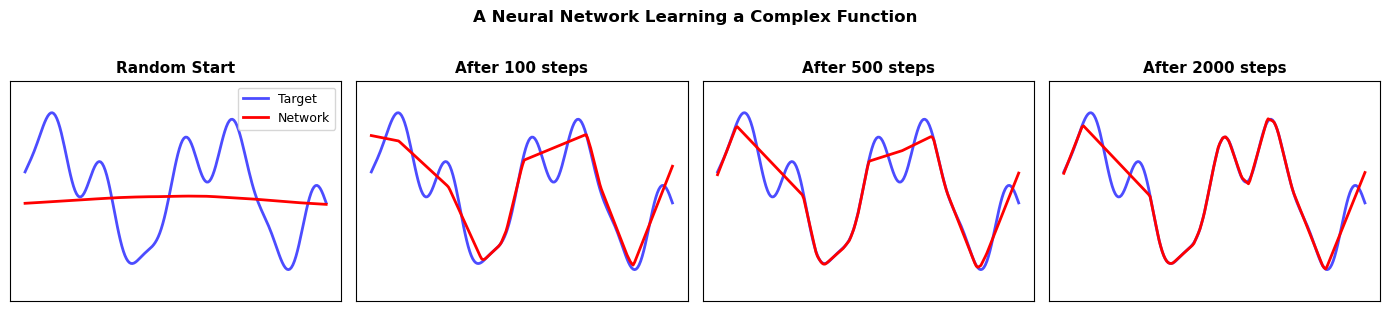

In [6]:
# A complex "squiggly" target function
def target_function(x):
    return np.sin(3*x) + 0.5*np.cos(7*x) + 0.3*np.sin(11*x)

# Generate training data
x_data = np.linspace(-2, 2, 200).reshape(-1, 1)
y_data = target_function(x_data)

# Simple neural network: 1 input → 32 hidden → 32 hidden → 1 output
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(1, 32), nn.ReLU(),
            nn.Linear(32, 32), nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.layers(x)

# Train it
net = SimpleNet()
optimizer = optim.Adam(net.parameters(), lr=0.01)
x_t = torch.tensor(x_data, dtype=torch.float32)
y_t = torch.tensor(y_data, dtype=torch.float32)

# Save predictions at different stages
stages = {0: None, 100: None, 500: None, 2000: None}
for epoch in range(2001):
    pred = net(x_t)
    loss = nn.MSELoss()(pred, y_t)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch in stages:
        stages[epoch] = pred.detach().numpy()

# Plot the learning progress
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
titles = ['Random Start', 'After 100 steps', 'After 500 steps', 'After 2000 steps']
for ax, (epoch, pred), title in zip(axes, stages.items(), titles):
    ax.plot(x_data, y_data, 'b-', linewidth=2, label='Target', alpha=0.7)
    ax.plot(x_data, pred, 'r-', linewidth=2, label='Network')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylim(-2, 2)
    ax.set_xticks([])
    ax.set_yticks([])
    if epoch == 0:
        ax.legend(loc='upper right', fontsize=9)
plt.suptitle('A Neural Network Learning a Complex Function', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

The network starts with random weights (red line is nowhere near blue). Through that same multiply-check-adjust loop, it gradually learns to trace the target function. By 2000 iterations, it's nearly perfect.

This is the **universal approximation theorem** in action: a neural network with enough neurons can approximate any continuous function to arbitrary accuracy. The network is essentially "drawing a squiggly line through your data" — and it can draw very complex squiggles.

We'll see exactly *how* it creates these bends later when we discuss activation functions. For now, just know: **neural networks are powerful function fitters.**

Now let's see how they're organized.

### Beyond Tabular Data: Learning from Images

The same principles apply to images. When you show a neural network thousands of pictures of cats and dogs, it learns to recognize them — but *how*?

In 2013, researchers Matt Zeiler and Rob Fergus published a groundbreaking paper that let us peek inside image-classifying neural networks. What they found was fascinating: **neural networks learn a hierarchy of features**.

**Early layers** learn simple patterns:
- Edges (horizontal, vertical, diagonal)
- Color gradients
- Basic textures

**Middle layers** combine these into more complex patterns:
- Corners and curves
- Repeating textures (fur, scales, fabric)
- Simple shapes

**Later layers** recognize high-level concepts:
- Eyes, noses, wheels
- Faces, objects, scenes

Here's what the first layer of a trained image classifier learned to detect:

In [ ]:
# Layer 1 features from Zeiler & Fergus (2013)
# The image shows a grid of learned first-layer filters from a CNN trained on ImageNet.
# Each small square represents what one neuron detects: edges at various angles,
# color gradients, and simple stripe/texture patterns.
# These are the basic visual building blocks the network discovers on its own.
print("(Zeiler & Fergus, 2013 - Layer 1 feature visualizations)")
print("First-layer neurons learn oriented edge detectors and color gradients.")
print("Similar to Gabor filters and V1 simple cells in human visual cortex.")

Each small square shows what one neuron has learned to detect. The first layer learns edge detectors at various angles and simple color patterns — the basic building blocks of vision.

Remarkably, these learned features are similar to what neuroscientists have found in the human visual cortex. The network *discovered* these patterns on its own, just by trying to classify images correctly.

**The key insight**: Whether it's tabular data (like Titanic passengers) or images, neural networks work the same way — they learn patterns by adjusting weights through that same multiply-check-adjust loop. The difference is just in what those patterns represent.

Now let's see how the architecture is organized.

## Part 2: What is a Neural Network?

A neural network is a series of **layers**, where each layer contains **neurons**. Data flows from left to right: it enters at the **input layer**, passes through one or more **hidden layers**, and exits at the **output layer**.

Here's what our Titanic survival predictor looks like:

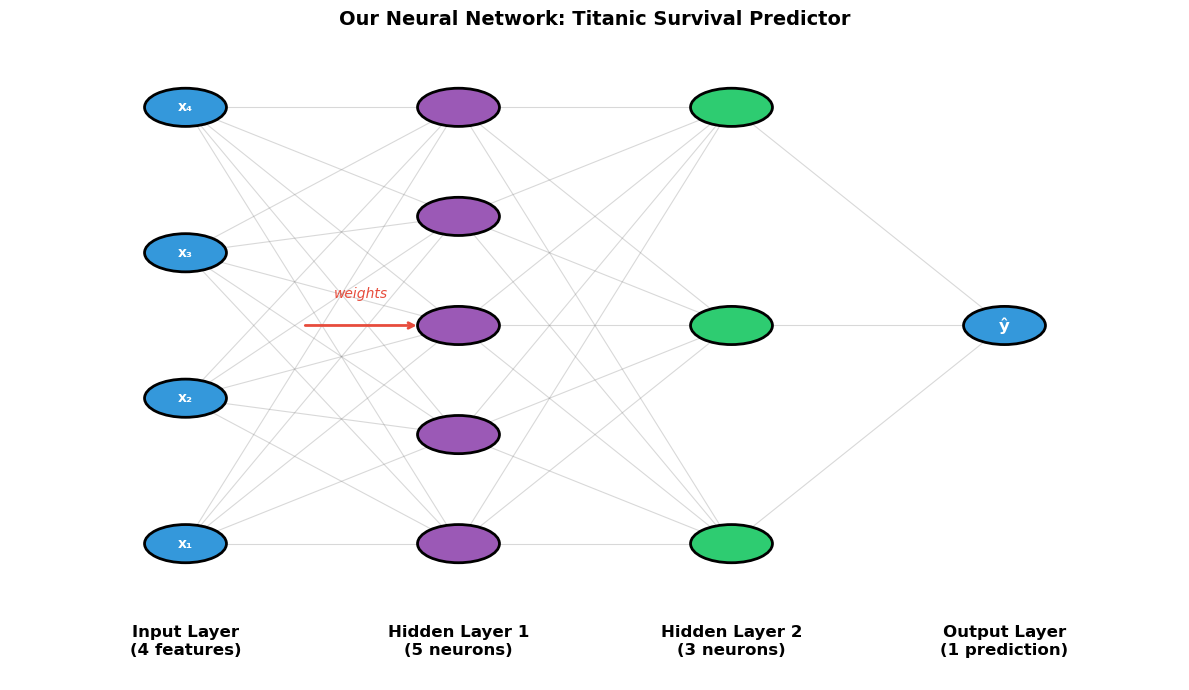

In [8]:
# Draw our network architecture: 4 inputs → 5 hidden → 3 hidden → 1 output
draw_neural_network(
    layer_sizes=[4, 5, 3, 1],
    layer_names=['Input Layer\n(4 features)', 'Hidden Layer 1\n(5 neurons)', 'Hidden Layer 2\n(3 neurons)', 'Output Layer\n(1 prediction)'],
    figsize=(12, 7),
    title="Our Neural Network: Titanic Survival Predictor"
)

**Key terminology:**

- **Input Layer**: Our 4 features (Pclass, Sex, Age, Fare) — one neuron per feature
- **Hidden Layers**: The layers between input and output — called "hidden" because we don't directly observe their values. Networks can have multiple hidden layers (ours has 2)
- **Output Layer**: 1 neuron that outputs P(survival)
- **Weights**: The lines connecting neurons — each line has a number that determines how much influence one neuron has on another
- **Deep Learning**: When a network has many hidden layers, we call it "deep" — that's where "deep learning" comes from

The "learning" happens in the weights. When we train the network, we're adjusting these connection strengths to make better predictions.

### What Does a Single Neuron Do?

Let's zoom in on one neuron to see what's happening inside:

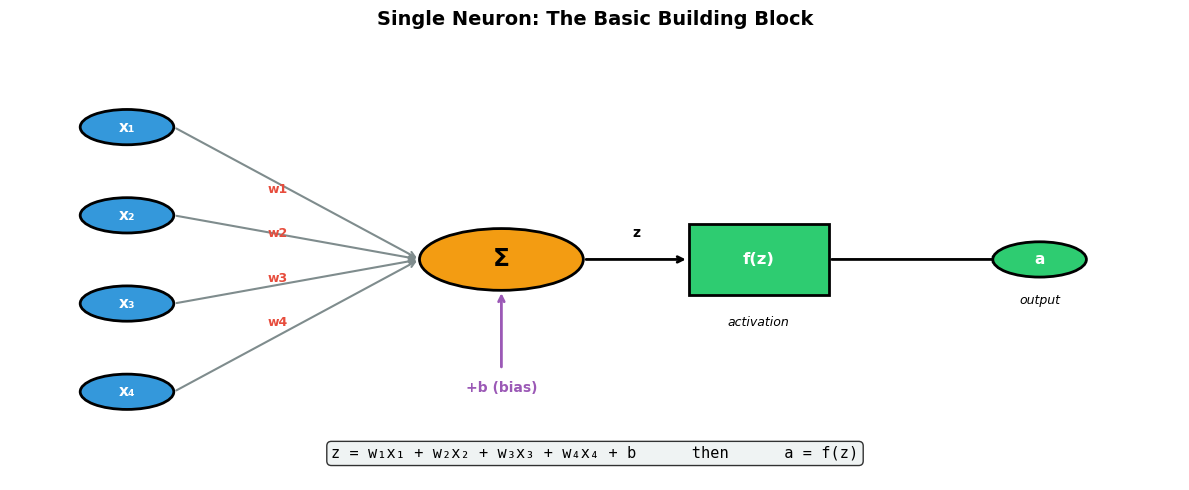

In [9]:
# Draw a single neuron in detail
draw_single_neuron_detailed(figsize=(12, 5))

A neuron is surprisingly simple. It does just three things:

1. **Multiply & Sum**: Take each input (x), multiply it by a weight (w), and add them all up
2. **Add Bias**: Add a bias term (b) — this lets the neuron "shift" its activation threshold
3. **Activate**: Pass the result through an activation function f(z) — this adds non-linearity

The formula: **a = f(w₁x₁ + w₂x₂ + w₃x₃ + w₄x₄ + b)**

That's it. The entire "intelligence" of a neural network comes from having many of these simple units, connected together, with learned weights.

### The Biological Inspiration

The name "neural network" comes from a loose analogy to biological brains. Real neurons receive signals through **dendrites**, process them in the **cell body**, and send output through an **axon**. Artificial neurons mimic this: inputs come in, get weighted and summed, then pass through an activation function.

But don't take the analogy too literally — artificial neurons are vastly simpler than biological ones. The comparison is more inspirational than technical:

<svg xmlns="http://www.w3.org/2000/svg" width="800" height="300" viewBox="0 0 800 300">
<rect width="100%" height="100%" fill="#fffef5"/>
<text x="400" y="25" text-anchor="middle" font-family="Arial, sans-serif" font-size="15" font-weight="bold">Biological Neuron</text>
<g transform="translate(200, 40)">
  <path fill="#AFA3CF" stroke="#000000" d="M126.833,132.089c3.606-1.491,1-6.333,1-6.333s-26.333-5-21-24s5.333-19,5.333-19  s6.333-4.668,11.667-8.334s3.667-4.999-0.667-3.666c-0.667-1.334,2.333-4.667,2.667-5.333c0.333-0.668,6-13.001-5.333,3.666  c0,1-9.667,12-4-7.666c0,0,7.333-35.334-1-9.668c0,0-2,6.334-4,2c0,0,4,13.335-8.333,46.001c-3-2.667-5-5.334-5-5.334  c-1-1.666-1.667-5.666,3-14.333s7.333-14,7.333-14s4.333-8.334-1-2.334c0,0,0.333-18.999-3,4.334c0,0-2.666,4.001-4.333,5.667  c0,0,4.667-11-1-8.333c0,0-3-7-2.667,1c0.333,7.999,2,9.667,1,14.333s-2.667,2.666-3-1.334s-10,0.334,5.333,24.667  c0,0,5.333,25.333-14.333,7.333c0,0-24.667-19.667,7-43c-4,3-5.667,6.335-5,2.334s0-3.667,0-3.667s-3.667,7.001-6,8.667  s-11.667,4.667,9-18.667c-4,3-11.333,8.667-4-7.667c-7,11-11.333,23.667-15.333,12.667c0,0,4.333,46.332-6,16.333  c0,0-3.667-6,5-35.667c-3,6.667-5.667,16-5-3.333c0,0-3,1-2.333,22.333c0,0-9.333,21.334-7.333-7c0,0,3-12.666,3.333-15  s-1.667,0.667-2.333,2s-0.667-5-0.667-5s-2,3-2.333,7s-3.333-3-4.333-4.667s6.666,11,1.333,21.666c0,0-7.666-12.666-8.333-9  c-0.667,3.667,16,23.668,16.333,25.001s10,11-2,9.333c-4-0.333-6.333-2.667-8.333-6s-6.333-10-6.333-10l-9.667-11L31.5,43.755  l-1.333,3.667l-2.333-2.333l2,4.667l0.333,6.333l-2.333,1c0,0,28,28.334,5.333,17.667c0,0-8.334,2.334,10.333,7  c0,0,1.333,7.666,17.333,8.666c0,0,12,13.001,15,25.334c0,0,3.333,26.667-12,6c0,0,3,7.333,1,7.333s-11.667-5.667-13-5.667  s-5.333,2-5.333,2s27,6.666,1.667,7c0,0-18,6.333-11-36c0,0-2.333,12.334-4.333,0.667c0,0-5.333,26.334,0,36.667  c0,0,5,6.332-2.333,6.666c0,0,9-1.334,18-4c0,0-6.667,13.334-10,13.334c0,0,3,0.666-0.333,2.666c0,0,1.333,2.666,5-2  s9-15.999,22-15.666c4.333,1.333,20.333,14.666-4,19.333c-7.333,3-35,13.001-32.667,14.667s16.333-8.334,14-3.334  s-10,19.334-10,19.334s9.333-21.333,7.333-5c1,1.333,25.333-45.333,8,0c0.333,1,4.333-6.001,5,3.333c0,0,0.333-35.332,25.333-24.666  c0.667,9-4.667,21.332-18.667,29.666c14.333-8.333,16.667-12,10,2c3.333-3.333,5-2.999,6,1.334c1.333-15,4-19.666,6.667-22  c2.667,7,3.667,9.999,4,11.666s-1.667-23.667-2-25s13-0.666,13-0.666s10,19.334,5.667,28c2.333-7.334-1.667-22.001,16,3.666  c0,0-12-13.333,7.333-8.333c-6.667-5.333-19-12.666-22.333-18.333s-4-13.333,6.333-6s16.667,10.332,17.667,9.666s-19.667-10,3.333-6  C116.5,151.756,92.167,146.422,126.833,132.089z" />
  <path fill="#E68B60" stroke="#000000" d="M85.125,136.589c-0.125-4.5,1.375-5.875,4.125-5.5s5.5,1.625,6.625,2.875s2.75,3.5,3,4.375  s0.375,1.75,0.5,2.625s0.5,1.75,0.125,2.5s-0.875,2.375-1.875,2.5s-1.625,0.375-2.75-0.25s-2.875-1.75-3.625-2.375  s-3.75-3.625-4.375-4.5S85.125,136.589,85.125,136.589z" />
  <path fill="#cccccc" stroke="#000000" d="M127.5,133.339c2.25-4.5,1.625-6,1.125-7.375s17.625-2,30,5c0,0,11.75,4,1.25,11.5  C159.875,142.464,140.375,145.339,127.5,133.339z" />
  <path fill="#cccccc" stroke="#000000" d="M168.375,145.839c0,0-3.625-1.75-2.5-5s2.125-3.25,3.125-3.625s6.75-0.25,7.25-0.25  s19.75,2,22.375,4.25s3.5,5,3.5,6.125s-0.25,4.75-3.75,4.75s-18.375-0.25-19-0.875S170.875,148.464,168.375,145.839z" />
  <path fill="#cccccc" stroke="#000000" d="M214.375,155.089c-6.625-2.125-9.5-4.625-9.25-7.25s0.75-3.625,1.875-4.25  s3.875-1.375,4.625-1.625s22.375-3.375,24.5-2.875s4.75,3,5,4.5s2.625,5-2.75,7.25s-9.375,3.75-13,4  S214.375,155.089,214.375,155.089z" />
  <path fill="#cccccc" stroke="#000000" d="M252.125,145.464c-6.009,0.376-7.875,1.125-7.75-3.375s-0.375-6.125,3.25-7.875  s13.875-8.5,15.5-9.25s6.875-2.375,9.25,0.75s2.125,4.5-0.375,7.25S256.125,145.214,252.125,145.464z" />
  <path fill="#cccccc" stroke="#000000" d="M274,122.839c-2.44-4.532-3.375-7-1.125-10.25s13.125-18.75,13.5-19.25  s4.625-2.375,8.375,0.875s4.5,5.5,1,10.25s-11.625,17.5-14.5,19S275.75,126.089,274,122.839z" />
  <ellipse fill="#E68B60" stroke="#B76328" cx="140" cy="130.964" rx="3.375" ry="2.125" />
  <ellipse fill="#E68B60" stroke="#B76328" cx="181.875" cy="144.839" rx="3.375" ry="2.125" />
  <ellipse fill="#E68B60" stroke="#B76328" cx="224.125" cy="147.839" rx="3.375" ry="2.125" />
  <ellipse transform="matrix(0.912 -0.4103 0.4103 0.912 -32.3066 117.8699)" fill="#E68B60" stroke="#B76328" cx="258.5" cy="134.214" rx="3.375" ry="2.125" />
  <ellipse transform="matrix(0.5422 -0.8402 0.8402 0.5422 39.543 287.5071)" fill="#E68B60" stroke="#B76328" cx="283.625" cy="107.464" rx="3.375" ry="2.125" />
  <path fill="#AFA3CF" stroke="#000000" d="M164.25,137.089c2.25,0.5,3.75,0.5,3.75,0.5l-2.125,3.25l-4.125-0.125L164.25,137.089z" />
  <path fill="#AFA3CF" stroke="#000000" d="M201.75,145.214l4.125-0.25L205,149.089h-3.125  C201.875,149.089,202.125,145.714,201.75,145.214z" />
  <path fill="#AFA3CF" stroke="#000000" d="M240.25,141.589c0,0,3.375-2.5,3.625-3.125s0.375,5,0.5,5.375s-2.25,0.875-2.25,0.875  L240.25,141.589z" />
  <path fill="#AFA3CF" stroke="#000000" d="M269.625,123.714l2.75-3.875l2.875,4.375l-2,1.875  C273.25,126.089,271.5,123.964,269.625,123.714z" />
  <path fill="#90EE90" stroke="#000000" d="M291.167,92.256c0.041-0.09,0.082-0.18,0.123-0.27c3.275-7.251,5.894-14.772,7.21-18.064  c1.333-3.333,1.833-11.166,1.333-12s-2-6.5-5.833-5.333s-2.501,0-3.667,1.833s-3.999,2-4.166,0.333s0.5-2.167,3.333-2.667  s1.333-2.5-0.667-4.333s-7.334-1.833-3.5-4.333s4-2.834,5.5-1.667s-3.167,2,1,4.5s7.166,4,8.5,4.167s2.5,0.333,2.5-1.167  s1.667-3,2.667-3.833s1.5-4.167,1.5-4.167s-3.5-3.166-0.5-2.833s4.5,0.5,3,2.333c0.333,0.5-0.166,2,0.167,2.5S315,47.089,315,47.089  s4.5-0.333,3,2.5c-0.333,0.833-1.5,2-3.5,0.667c-1.833,0.333-3.667-0.333-4.167-0.167s-7.167,3.167-6.5,18.167  c4.5-2.5,17.668-10.334,19.334-11s9.666-9.833,9.833-10.667s-1.666-3.333-1.333-4s3.499-2,4.166-2.167s1.501-2,2.334,0.167  s0.667,2.167,0,2.667s-1.166,0.833-1,1.833s0.333,1.667,0.833,1.5s0.833,0.833,0.833,0.833l-6.666,5.333c0,0,6.167-1.167,7-2  s2.5-1.667,2.833-0.5s0.667,0.834,0,1.667s-1.833,1.666-4,2.333s-3.667,1.333-5,1.5s-3.833,1-3.833,1s-1.333,0.333-4,2.5  s-4.5,3.167-6.167,4.167s-2.833,1.333-4.5,2.5s-4.5,2.5-4.5,2.5s-2.501,0.834-3.167,1.667s-1.832,2.167-2.166,2.667  s-1,2.166-1,2.166l-0.667,3l-2.167,2.5l-0.5,2.334c0,0,4.166,0.5,5,0.5s1.5-0.001,2.667-0.834s1-0.334,2-1.5  s2.167-2.333,2.667-3.333s1.666-2.167,2.666-3s2.333-2.001,3-2.167s3-0.833,3.5-1.333s1.001,0.001,1.334-0.833s1.334-2.5,1.5-3.333  s0.166-1.167,0.833-1.167s1.167-0.333,1.5,0.5s1.001,0.667,0.667,1.833S327,69.922,327,69.922l0.167,0.334c0,0,1.5,0.499,2-0.334  s1.333-1.333,1.333-1.333l1-1.333l0.833-1.5l0.834-0.667l1.5-0.333c0,0,0.5,0,0.833,1.167s0.5,1.667,0.5,2.167s-2,2-2,2  l-0.667,0.667c0,0-1.5,0.332-2,0.666s-2.166,0.834-2.166,0.834l-2.334,0.166l-1.666,0.834l-0.667,0.5v1c0,0,0.667,0.834,1.167,1  s3.5,0,3.5,0l0.666-0.167l-1,1.333l-3.333,0.667c0,0-0.834,0.166-1.667,0.333s-3,0.5-3,0.5s-1.834,0.834-2.5,1.334s-2,0.167-0.833,1  s0.333,1.334,4,1s1.334-0.667,4.667,0.333s4,0.667,6,1.667s-1.334,0.332,4.333,2.166s5.499,1.666,9.333,3s3.333-0.5,4.5,2  s6.667,2.833,1.167,2.5s-4.499-0.333-7.333-1.333s-2.5-1.167-6.667-2.667s-6.667-3.667-2.167,1.5s5.5,5.667,6.167,10.167  s1,14.167,5,14.5s7.501,1.333,5.167,3.333s-6.168,0.668-7.334-1.166s-3.666-3.5-4.166-6s0.334-4.501-0.5-4.834  s-0.834-0.332-1.667,0.334s-0.333-0.834-1.5,1.833s-1.501,3.167-2.167,3.5s-4.166,0.834-4.166-0.833s0.5-2.168,1.333-2.334  s-0.667,1.333,2-1s3.834-4.166,4.167-5.166s2.166-5.5-5.667-11.167s-13.666-9.166-20.833-5.833c2,3,5.667,5.333,5.5,11.333  c0,0.667,2.832,3-0.334,4c-0.5,0.167-3.5,0.333-1.833-4c0-2.167,0.501-3.499-3.833-7.333c0.166,3.666-0.168,7.332,0.166,8.666  s3.168,4.501-0.666,5.834c-2.167-0.5-3.834-1.833-1.334-6c0-3.834-3.999-20.333-14.166-5  C292.333,93.089,291.167,92.256,291.167,92.256z" />
  <path fill="#AFA3CF" stroke="#000000" d="M367.333,131.756" />
  <line stroke="#000000" x1="142.5" y1="78.089" x2="111.5" y2="118.589" />
  <line stroke="#000000" x1="127.5" y1="133.339" x2="143" y2="162.089" />
  <line stroke="#000000" x1="227" y1="155.089" x2="227.5" y2="183.589" />
  <text transform="matrix(1 0 0 1 138 76.5889)" font-family="'Verdana'" font-size="14">Cell body</text>
  <text transform="matrix(1 0 0 1 140 176.0889)" font-family="'Verdana'" font-size="14">Axon</text>
  <text transform="matrix(1 0 0 1 219.5 198.0889)" font-family="'Verdana'" font-size="14">Myelin sheath</text>
</g>
<text x="120" y="110" font-family="Verdana" font-size="14" font-weight="bold" fill="#333">Dendrites</text>
<text x="120" y="130" font-family="Verdana" font-size="12" fill="#555">(data input)</text>
<text x="570" y="105" font-family="Verdana" font-size="14" font-weight="bold" fill="#333">Axon terminal</text>
<text x="570" y="125" font-family="Verdana" font-size="12" fill="#555">(data output)</text>
<rect x="390" y="140" width="30" height="20" fill="#666" opacity="0.7"/>
<polygon points="420,130 420,170 440,150" fill="#666" opacity="0.7"/>
<rect x="0" y="0" width="800" height="300" fill="none" stroke="#ccc" stroke-width="1"/>
</svg>

<svg xmlns="http://www.w3.org/2000/svg" width="800" height="300" viewBox="0 0 800 300">
<rect width="100%" height="100%" fill="#f5f8ff"/>
<g transform="translate(100, 0) scale(0.75)">
  <text x="400" y="30" text-anchor="middle" font-family="Arial, sans-serif" font-size="20" font-weight="bold">Artificial Neuron</text>
  <g id="inputs">
    <circle cx="100" cy="100" r="20" fill="#e8e8f0" stroke="#333" stroke-width="2"/>
    <text x="100" y="107" text-anchor="middle" font-family="Arial" font-size="14">x₁</text>
    <circle cx="100" cy="170" r="20" fill="#e8e8f0" stroke="#333" stroke-width="2"/>
    <text x="100" y="177" text-anchor="middle" font-family="Arial" font-size="14">x₂</text>
    <circle cx="100" cy="240" r="20" fill="#e8e8f0" stroke="#333" stroke-width="2"/>
    <text x="100" y="247" text-anchor="middle" font-family="Arial" font-size="14">x₃</text>
    <text x="100" y="290" text-anchor="middle" font-family="Arial" font-size="16">⋮</text>
    <circle cx="100" cy="330" r="20" fill="#e8e8f0" stroke="#333" stroke-width="2"/>
    <text x="100" y="337" text-anchor="middle" font-family="Arial" font-size="14">xₙ</text>
  </g>
  <text x="20" y="220" font-family="Arial" font-size="18" font-weight="bold" text-anchor="middle" transform="rotate(-90 20 220)">Inputs</text>
  <text x="40" y="220" font-family="Arial" font-size="16" text-anchor="middle" transform="rotate(-90 40 220)">(data input)</text>
  <g id="weights" stroke="#666" stroke-width="2" fill="none">
    <line x1="120" y1="100" x2="280" y2="180"/>
    <line x1="120" y1="170" x2="280" y2="190"/>
    <line x1="120" y1="240" x2="280" y2="200"/>
    <line x1="120" y1="330" x2="280" y2="220"/>
  </g>
  <text x="180" y="130" font-family="Arial" font-size="12" fill="#666">w₁</text>
  <text x="180" y="175" font-family="Arial" font-size="12" fill="#666">w₂</text>
  <text x="180" y="215" font-family="Arial" font-size="12" fill="#666">w₃</text>
  <text x="180" y="280" font-family="Arial" font-size="12" fill="#666">wₙ</text>
  <circle cx="300" cy="200" r="40" fill="#AFA3CF" stroke="#333" stroke-width="2"/>
  <text x="300" y="208" text-anchor="middle" font-family="Arial" font-size="24" font-weight="bold">Σ</text>
  <text x="300" y="260" text-anchor="middle" font-family="Arial" font-size="12">Weighted Sum</text>
  <line x1="340" y1="200" x2="420" y2="200" stroke="#333" stroke-width="2" marker-end="url(#arrowhead)"/>
  <rect x="420" y="170" width="100" height="60" rx="10" fill="#F9D566" stroke="#333" stroke-width="2"/>
  <text x="470" y="192" text-anchor="middle" font-family="Arial" font-size="14">Activation</text>
  <text x="470" y="207" text-anchor="middle" font-family="Arial" font-size="14">Function</text>
  <text x="470" y="222" text-anchor="middle" font-family="Arial" font-size="12" fill="#666">σ(z)</text>
  <line x1="520" y1="200" x2="600" y2="200" stroke="#333" stroke-width="2" marker-end="url(#arrowhead)"/>
  <circle cx="630" cy="200" r="30" fill="#90EE90" stroke="#333" stroke-width="2"/>
  <text x="630" y="207" text-anchor="middle" font-family="Arial" font-size="16" font-weight="bold">y</text>
  <text x="680" y="195" font-family="Arial" font-size="18" font-weight="bold">Output</text>
  <text x="680" y="215" font-family="Arial" font-size="16">(data output)</text>
  <circle cx="300" cy="100" r="20" fill="#f0f0f0" stroke="#333" stroke-width="2"/>
  <text x="300" y="107" text-anchor="middle" font-family="Arial" font-size="14">+1</text>
  <text x="300" y="75" text-anchor="middle" font-family="Arial" font-size="12" fill="#666">bias</text>
  <line x1="300" y1="120" x2="300" y2="160" stroke="#666" stroke-width="2" stroke-dasharray="5,5"/>
  <text x="310" y="140" font-family="Arial" font-size="12" fill="#666">b</text>
  <text x="400" y="360" text-anchor="middle" font-family="Arial" font-size="18" fill="#333">y = σ(Σxᵢwᵢ + b) = σ(x₁w₁ + x₂w₂ + ... + xₙwₙ + b)</text>
</g>
  <defs>
    <marker id="arrowhead" markerWidth="10" markerHeight="7" 
     refX="10" refY="3.5" orient="auto">
      <polygon points="0 0, 10 3.5, 0 7" fill="#333" />
    </marker>
  </defs>
  <rect x="0" y="0" width="800" height="300" fill="none" stroke="#ccc" stroke-width="1"/>
</svg>

### From Concept to Code: Tracing Real Data

Now that we understand the architecture, let's see exactly how numbers flow through the network. To keep the visualizations clear, we'll trace through a simpler network with just one hidden layer (5 neurons). The principles are identical for deeper networks — just more layers of the same operations.

First, let's look at our data:

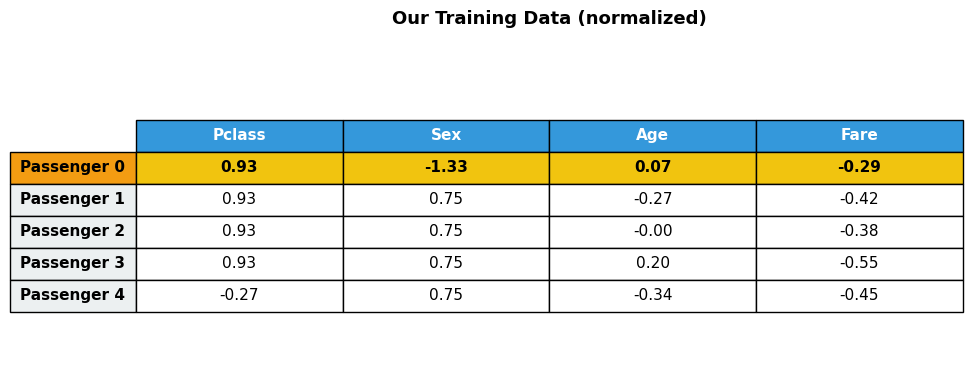

In [10]:
# Show the first 5 passengers as a table
sample_data = X_train_norm[:5]
sample_labels = [f'Passenger {i}' for i in range(5)]
feature_labels = ['Pclass', 'Sex', 'Age', 'Fare']

show_data_table(
    sample_data,
    row_labels=sample_labels,
    col_labels=feature_labels,
    title="Our Training Data (normalized)",
    highlight_row=0  # We'll trace Passenger 0
)

Each row is one passenger. Each column is one feature (normalized so they're on similar scales).

Let's trace **Passenger 0** (highlighted in yellow) through the network. First, we extract their row:

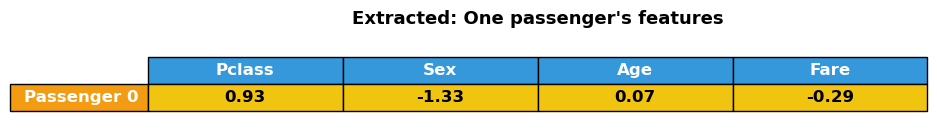

This passenger: Pclass=0.93, Sex=-1.33, Age=0.07, Fare=-0.29


In [11]:
# Extract Passenger 0's row
show_extracted_row(
    sample_data, 
    row_idx=0, 
    col_labels=feature_labels,
    row_label='Passenger 0',
    title="Extracted: One passenger's features"
)

# Store for later use
input_row = sample_data[0]
print(f"This passenger: Pclass={input_row[0]:.2f}, Sex={input_row[1]:.2f}, Age={input_row[2]:.2f}, Fare={input_row[3]:.2f}")

### The Weight Matrix: Each Row is One Neuron

Now let's look at the weights. We'll use 5 neurons in our hidden layer, so we have a 5×4 weight matrix — 5 neurons, each with 4 weights (one per input feature).

**Each row represents one neuron's weights** — its "recipe" for combining the 4 input features. This is exactly how PyTorch stores weights: shape `(out_features, in_features)` = `(neurons, features)`.

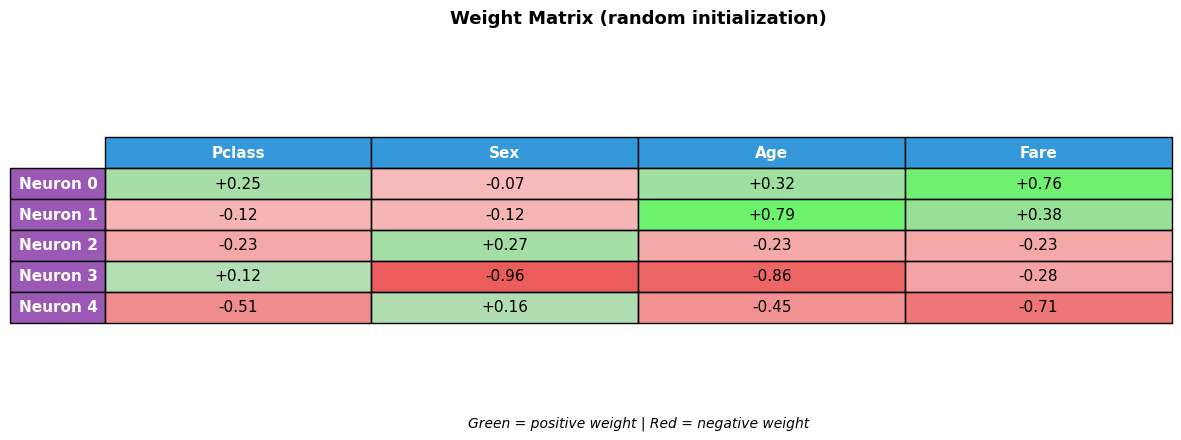


Why random? If all weights started at zero, every neuron would compute
the same thing and learn identically. Random initialization breaks this
symmetry — each neuron starts differently, so they specialize during training.


In [12]:
# Create random weights for 5 neurons (same as PyTorch's random initialization)
np.random.seed(42)
n_neurons = 5
weight_matrix = np.random.randn(n_neurons, 4) * 0.5  # 5 neurons × 4 features
biases = np.random.randn(n_neurons) * 0.1

neuron_labels = [f'Neuron {i}' for i in range(n_neurons)]

# Show weight matrix as a table (neurons as rows)
show_weight_table(
    weight_matrix,
    feature_labels=feature_labels,
    neuron_labels=neuron_labels,
    title="Weight Matrix (random initialization)"
)

print("\nWhy random? If all weights started at zero, every neuron would compute")
print("the same thing and learn identically. Random initialization breaks this")
print("symmetry — each neuron starts differently, so they specialize during training.")

Each row is one neuron. Each neuron has 4 weights — one for each input feature.

Now watch what happens when Passenger 0 goes through **Neuron 0** (highlighted):

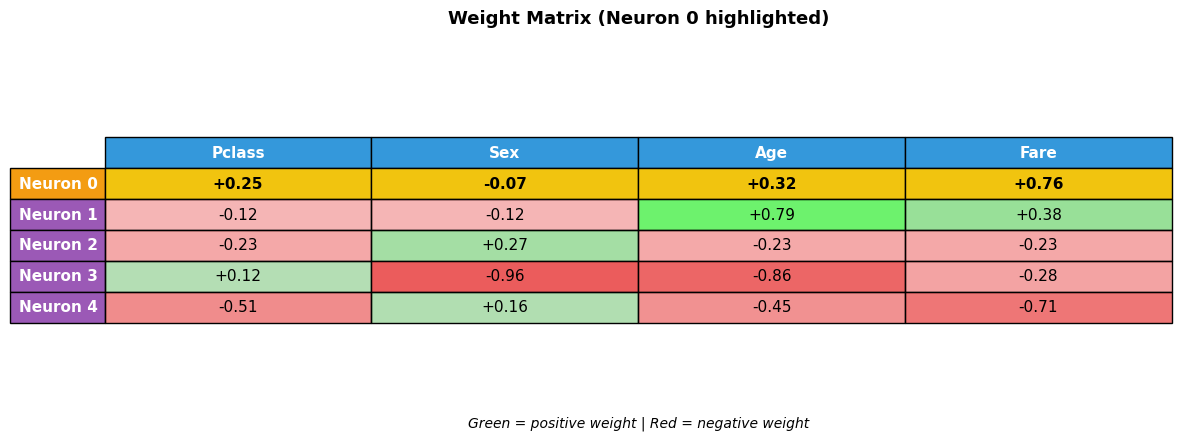

In [13]:
# Show weight matrix again with Neuron 0 highlighted
show_weight_table(
    weight_matrix,
    feature_labels=feature_labels,
    neuron_labels=neuron_labels,
    title="Weight Matrix (Neuron 0 highlighted)",
    highlight_neuron=0
)

### Visualizing the Multiplication: Input Row × Weight Matrix

Let's see how the input row (one passenger) interacts with the weight matrix (all neurons). Each input value gets multiplied by the corresponding weight in **each neuron's row**:

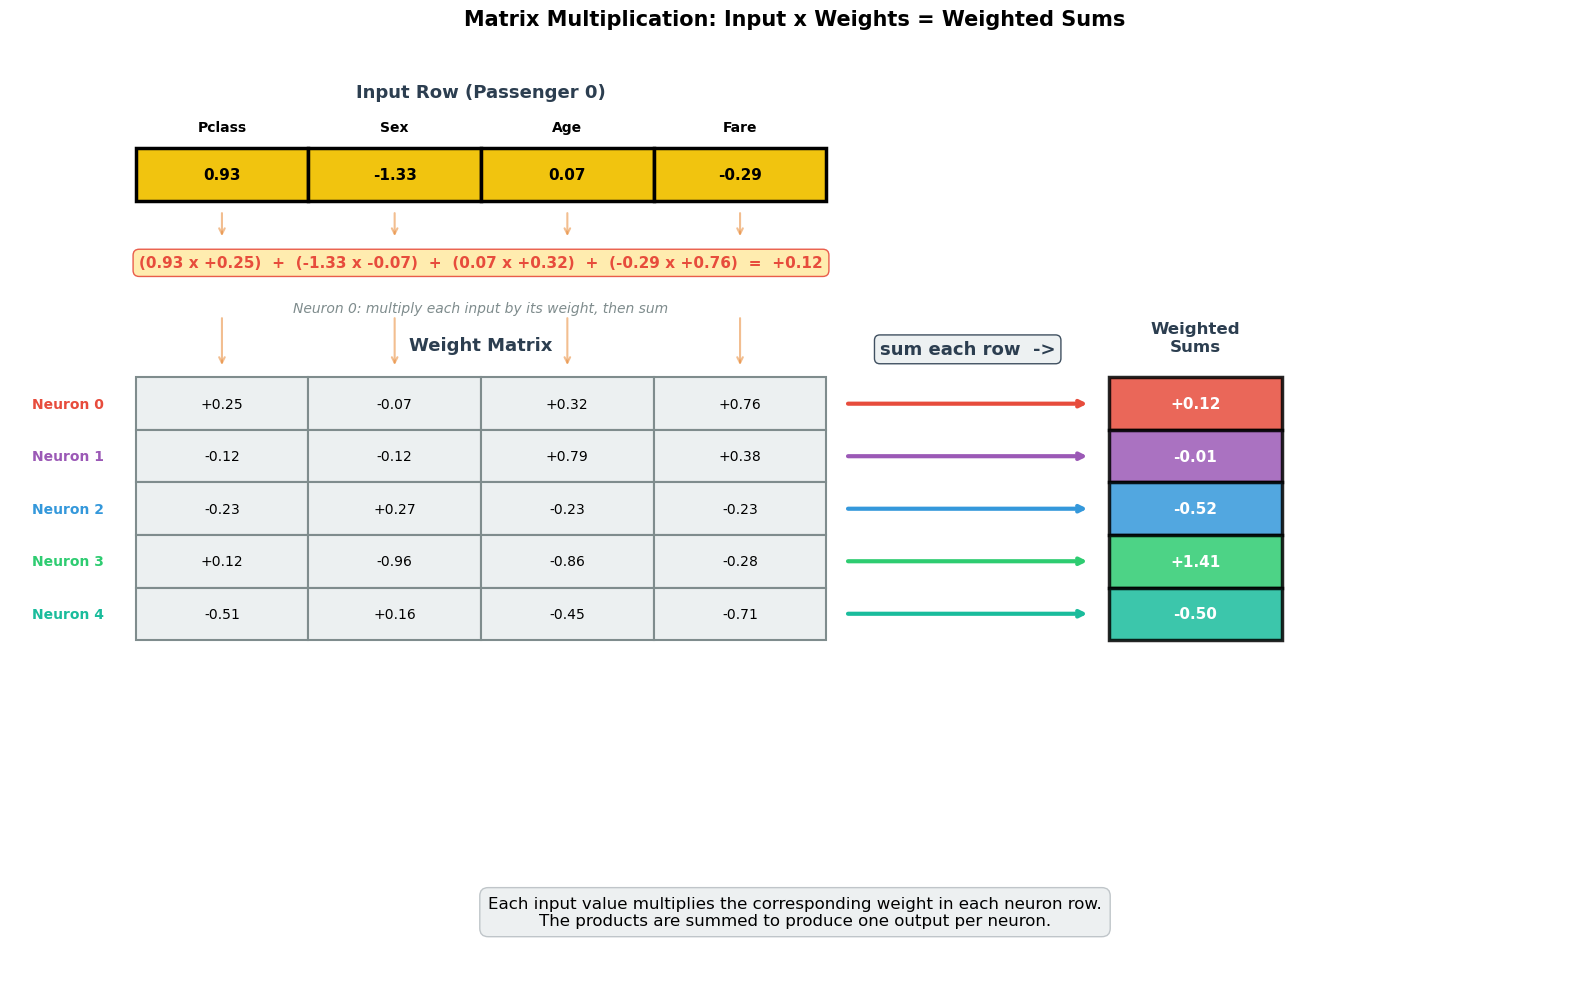

In [14]:
# Visualize the matrix multiplication with formula
show_matrix_multiplication_formula(input_row, weight_matrix, feature_labels, neuron_labels)

The formula above shows how **one value** (the first neuron's output) is computed. But all 5 neurons process the same input simultaneously, each with their own weights.

Let's see the complete picture — from input, through multiplications, to final outputs:

This is what happens **in one layer**:

1. **Multiply**: Each input × each weight in the matrix
2. **Sum rows**: Add up each row to get one value per neuron  
3. **Add bias**: Shift each neuron's output
4. **Apply ReLU**: Zero out negatives, keep positives

The result is 5 numbers — one per neuron — which become the input to the next layer. The **forward pass** is this process repeated through all layers until we get our final prediction.

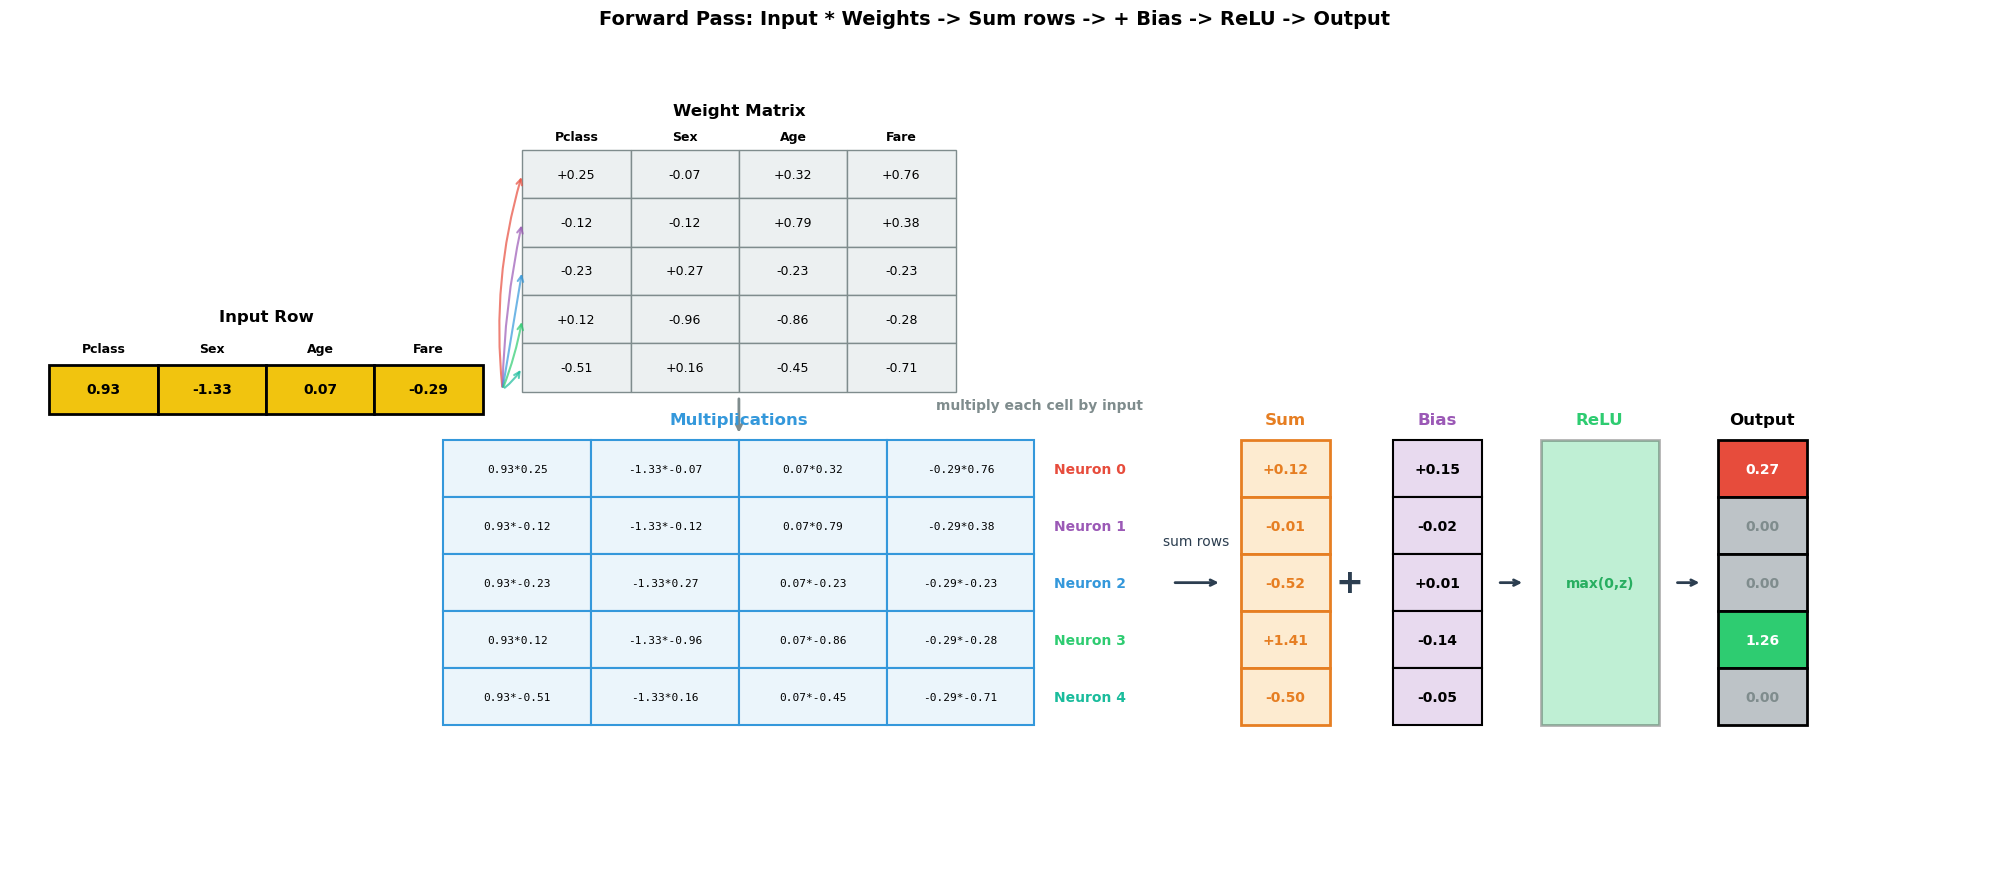

In [15]:
# Visualize the complete forward pass with all steps
hidden_outputs = show_forward_pass_detailed(input_row, weight_matrix, biases, feature_labels, neuron_labels)

### Key Insight: Each Neuron is One Row of Weights

Look at the weight matrix again:
- **Row 0** = Neuron 0's recipe for combining inputs
- **Row 1** = Neuron 1's recipe
- etc.

Each neuron takes the SAME input but applies DIFFERENT weights, producing DIFFERENT outputs. That's how the network learns multiple features simultaneously.

We traced one passenger through one layer. But real networks process **many passengers through multiple layers**. Let's see how that works.

## Part 3: The Complete Forward Pass

In practice, we process many passengers at once through all layers. This is where **matrix multiplication** shines — it handles the entire batch in one operation.

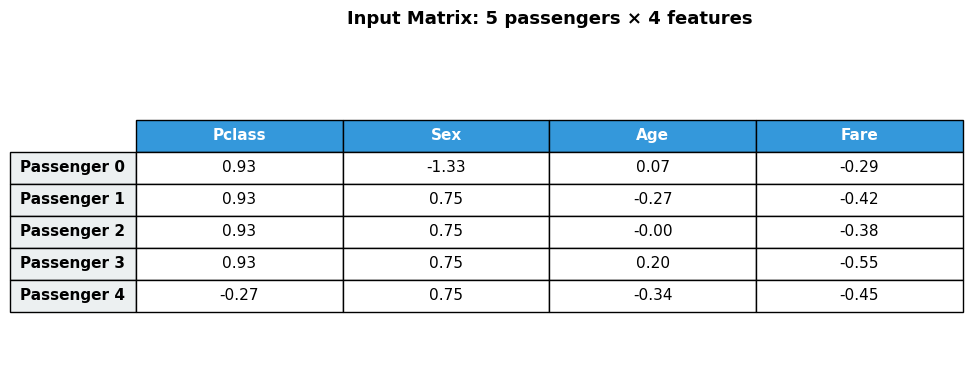

In [16]:
# Reminder: our input data (5 passengers × 4 features)
show_data_table(
    sample_data,
    row_labels=sample_labels,
    col_labels=feature_labels,
    title="Input Matrix: 5 passengers × 4 features"
)

### Matrix Multiplication: The Magic Formula

To process all passengers through all neurons, we compute:

**Result = Input @ Weights.T**

Why transpose? Because our weight matrix has shape (5 neurons × 4 features), but we need (4 features × 5 neurons) for the matrix multiply to work. Here's the full picture:

In [17]:
# Create network weights using PyTorch (same random seed for reproducibility)
torch.manual_seed(42)
layer1 = nn.Linear(4, 5)   # 4 inputs → 5 hidden neurons
layer2 = nn.Linear(5, 1)   # 5 hidden → 1 output

# Extract weights as numpy arrays
W1 = layer1.weight.detach().numpy()  # Shape: (5, 4)
b1 = layer1.bias.detach().numpy()    # Shape: (5,)
W2 = layer2.weight.detach().numpy()  # Shape: (1, 5)
b2 = layer2.bias.detach().numpy()    # Shape: (1,)

print(f"Layer 1: {W1.shape[1]} inputs → {W1.shape[0]} neurons = {W1.size + b1.size} parameters")
print(f"Layer 2: {W2.shape[1]} inputs → {W2.shape[0]} output  = {W2.size + b2.size} parameters")
print(f"Total: {W1.size + b1.size + W2.size + b2.size} trainable parameters")

Layer 1: 4 inputs → 5 neurons = 25 parameters
Layer 2: 5 inputs → 1 output  = 6 parameters
Total: 31 trainable parameters


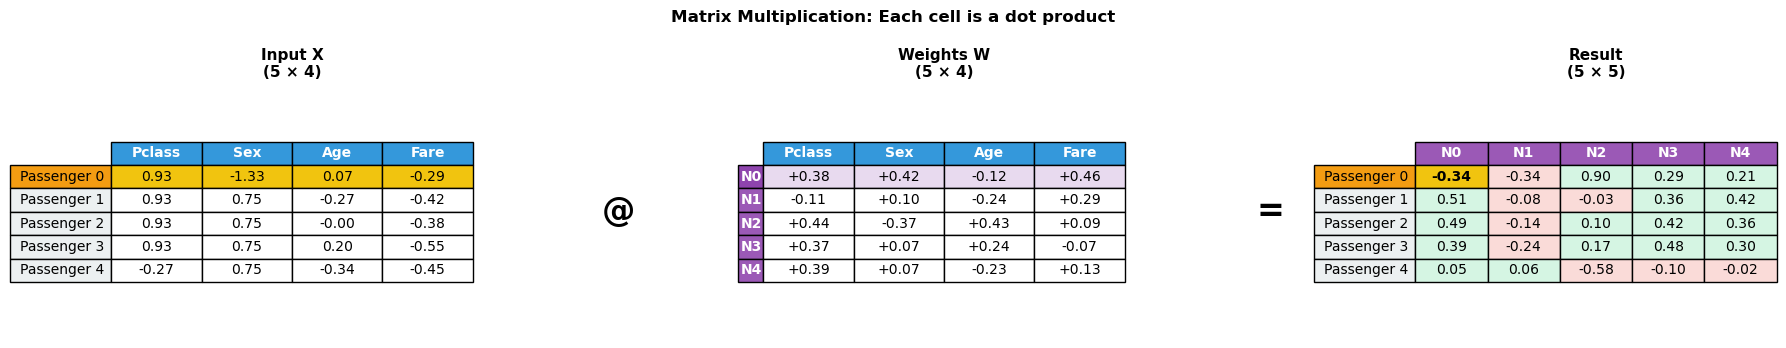

In [18]:
# Compute the matrix multiplication: Input (5×4) @ Weights.T (4×5) = Result (5×5)
# Note: W1 has shape (5 neurons, 4 features), so W1.T has shape (4 features, 5 neurons)

result_no_bias = sample_data @ W1.T  # Shape: (5 passengers, 5 neurons)

# Show the computation
show_matrix_multiply_step(
    X=sample_data,
    W=W1,  # Our function expects (n_neurons, n_features) and displays it as rows
    result=result_no_bias,
    sample_labels=sample_labels,
    feature_labels=feature_labels,
    neuron_labels=[f'N{i}' for i in range(5)],
    highlight_sample=0,
    highlight_neuron=0
)

### Reading the Result Matrix

Each cell in the result is one dot product:
- **Row** = which passenger
- **Column** = which neuron

The highlighted cell (Passenger 0, Neuron 0) is exactly the computation we traced in Part 2!

### Batch Results

After matrix multiplication, adding bias, and applying ReLU — we have hidden activations for all 5 passengers:

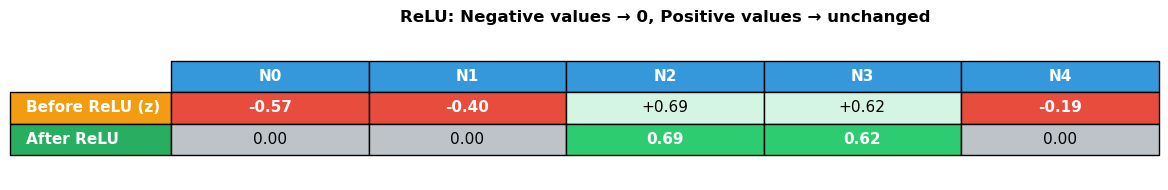

In [19]:
# Add bias and apply ReLU
z1 = result_no_bias + b1  # Broadcasting: b1 shape (5,) gets added to each row
a1 = np.maximum(0, z1)    # ReLU: negative values become 0

# Show before/after ReLU for Passenger 0
plot_relu_comparison(
    before=z1[0],
    after=a1[0],
    labels=[f'N{i}' for i in range(5)]
)

Hidden Layer Outputs (after ReLU):


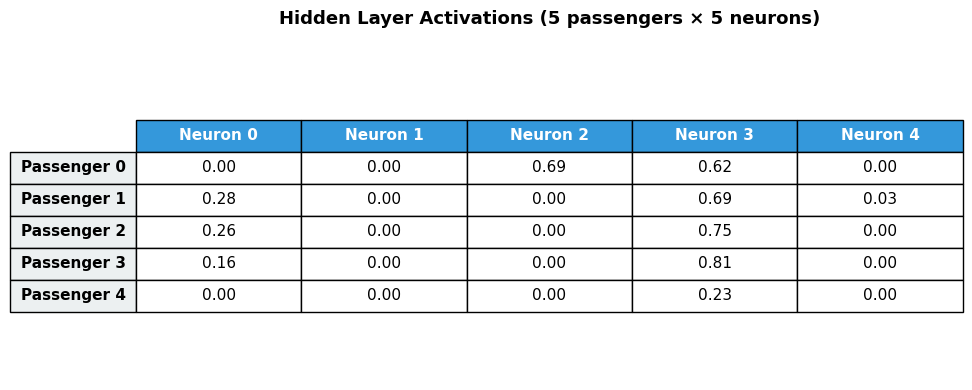

Passenger 0: 2/5 neurons activated
Passenger 1: 3/5 neurons activated
Passenger 2: 2/5 neurons activated
Passenger 3: 2/5 neurons activated
Passenger 4: 1/5 neurons activated


In [20]:
# Show the hidden layer outputs for all passengers
print("Hidden Layer Outputs (after ReLU):")
show_data_table(
    a1,
    row_labels=sample_labels,
    col_labels=[f'Neuron {i}' for i in range(5)],
    title="Hidden Layer Activations (5 passengers × 5 neurons)"
)

# Count active neurons per passenger
for i in range(5):
    active = (a1[i] > 0).sum()
    print(f"Passenger {i}: {active}/5 neurons activated")

### Layer 2: Hidden → Output

Now these 5 hidden activations become inputs to the output layer. Same process: matrix multiply + bias + sigmoid.

Layer 2 Weights (1 output neuron):


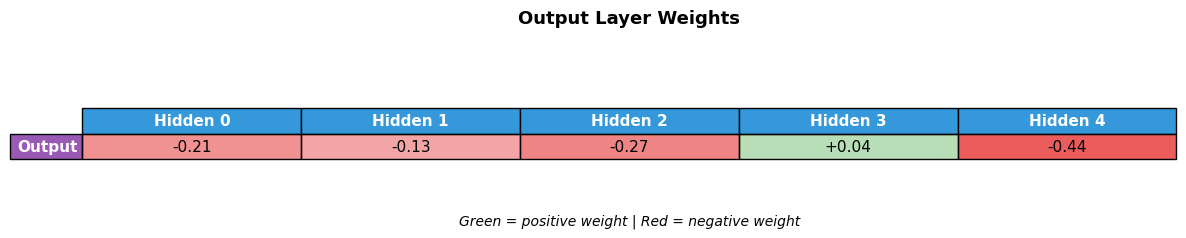


Final Predictions:
Passenger 0: z=+0.244 → P(survived)=0.561 → Survived (actual: Survived) ✓
Passenger 1: z=+0.363 → P(survived)=0.590 → Survived (actual: Died) ✗
Passenger 2: z=+0.382 → P(survived)=0.594 → Survived (actual: Died) ✗
Passenger 3: z=+0.405 → P(survived)=0.600 → Survived (actual: Died) ✗
Passenger 4: z=+0.414 → P(survived)=0.602 → Survived (actual: Died) ✗


In [21]:
# Layer 2: 5 hidden → 1 output
# W2 shape: (1 neuron, 5 inputs)

z2 = a1 @ W2.T + b2  # (5 passengers, 1 output)
probabilities = sigmoid(z2)

# Show the computation
print("Layer 2 Weights (1 output neuron):")
show_weight_table(
    W2,
    feature_labels=[f'Hidden {i}' for i in range(5)],
    neuron_labels=['Output'],
    title="Output Layer Weights"
)

print("\nFinal Predictions:")
print("=" * 60)
for i in range(5):
    z = z2[i, 0]
    p = probabilities[i, 0]
    actual = y_train[i]
    pred = "Survived" if p >= 0.5 else "Died"
    actual_str = "Survived" if actual else "Died"
    match = "✓" if (p >= 0.5) == actual else "✗"
    print(f"Passenger {i}: z={z:+.3f} → P(survived)={p:.3f} → {pred} (actual: {actual_str}) {match}")

### Forward Pass Summary

That's the complete forward pass:

```
Input (5 × 4) → Layer 1: @W1.T + b1 → ReLU → Hidden (5 × 5) → Layer 2: @W2.T + b2 → Sigmoid → Output (5 × 1)
```

With random weights, the predictions are basically random guesses. Training will adjust the weights to make better predictions.

In [22]:
# Verify our manual computation matches PyTorch
torch.manual_seed(42)
pytorch_model = nn.Sequential(
    nn.Linear(4, 5),
    nn.ReLU(),
    nn.Linear(5, 1),
    nn.Sigmoid()
)

with torch.no_grad():
    pytorch_output = pytorch_model(torch.FloatTensor(sample_data)).numpy()

print("Verification: Manual vs PyTorch")
print("=" * 45)
for i in range(5):
    manual = probabilities[i, 0]
    pytorch = pytorch_output[i, 0]
    print(f"Passenger {i}: Manual={manual:.6f}, PyTorch={pytorch:.6f}")
print("\n✓ They match! (tiny differences are floating point)")

Verification: Manual vs PyTorch
Passenger 0: Manual=0.560578, PyTorch=0.560578
Passenger 1: Manual=0.589675, PyTorch=0.589675
Passenger 2: Manual=0.594287, PyTorch=0.594287
Passenger 3: Manual=0.599920, PyTorch=0.599920
Passenger 4: Manual=0.601989, PyTorch=0.601989

✓ They match! (tiny differences are floating point)


In [23]:
# Define a helper function for the forward pass
def forward_pass_manual(X, W1, b1, W2, b2):
    """Manual forward pass through a 2-layer network."""
    z1 = X @ W1.T + b1
    a1 = np.maximum(0, z1)  # ReLU
    z2 = a1 @ W2.T + b2
    return sigmoid(z2)

### Key Takeaways from the Forward Pass

1. **Each row in the weight matrix = one neuron's "recipe"** for combining inputs
2. **Matrix multiplication** processes all samples through all neurons at once
3. **The shape rule**: `(samples × features) @ (features × neurons) = (samples × neurons)`
4. **ReLU** turns off negative values — creating sparse, specialized activations
5. **It's all just multiplication and addition** — the "magic" is in learning good weights

### Why ReLU Matters: The Secret to "Squiggly Lines"

Remember how we showed a neural network learning any complex function? ReLU is the key.

Without an activation function, stacking layers would just give us another linear function — no matter how many layers, you'd only ever get straight lines. But ReLU introduces a "bend" at zero. Each neuron can create one bend, and by combining many neurons, we can approximate any curve.

Think of it like this: **each ReLU neuron contributes one piece of a piecewise linear function.** Stack enough pieces together, and you can trace any shape — no matter how "squiggly."

This is the **universal approximation theorem** we mentioned earlier: with enough neurons and these simple ReLU bends, neural networks can approximate any continuous function to arbitrary accuracy.

## Part 4: The Loss Function — Measuring Error

After the forward pass, we have predictions. Now we need to measure how wrong they are.

For binary classification, we use **binary cross-entropy loss**. The intuition is simple:

| True Label | Prediction | Loss | Meaning |
|------------|------------|------|---------|
| 1 (survived) | 0.99 | 0.01 | Very confident and correct → tiny loss |
| 1 (survived) | 0.70 | 0.36 | Fairly confident → small loss |
| 1 (survived) | 0.50 | 0.69 | Barely confident (on the boundary) |
| 1 (survived) | 0.10 | 2.30 | Thought wrong class → high loss |
| 1 (survived) | 0.01 | 4.60 | Confidently wrong → huge loss |

The loss punishes confident wrong predictions severely. This is what drives the network to learn.

In [24]:
def binary_cross_entropy(y_true, y_pred):
    """Compute binary cross-entropy loss."""
    epsilon = 1e-15  # Avoid log(0)
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# Show loss for different predictions when true label is 1
print("True label = 1 (survived)")
print("="*45)
predictions_demo = [0.99, 0.9, 0.7, 0.5, 0.3, 0.1, 0.01]
for pred in predictions_demo:
    loss = binary_cross_entropy(np.array([1]), np.array([pred]))
    quality = "✓ Correct" if pred >= 0.5 else "✗ Wrong"
    bar = "█" * int(min(loss * 5, 20))
    print(f"  Predict {pred:.2f} → Loss: {loss:.3f} {bar} {quality}")

True label = 1 (survived)
  Predict 0.99 → Loss: 0.010  ✓ Correct
  Predict 0.90 → Loss: 0.105  ✓ Correct
  Predict 0.70 → Loss: 0.357 █ ✓ Correct
  Predict 0.50 → Loss: 0.693 ███ ✓ Correct
  Predict 0.30 → Loss: 1.204 ██████ ✗ Wrong
  Predict 0.10 → Loss: 2.303 ███████████ ✗ Wrong
  Predict 0.01 → Loss: 4.605 ████████████████████ ✗ Wrong


In [25]:
# Compute loss for our untrained network on the training data
predictions_untrained = forward_pass_manual(X_train_norm, W1, b1, W2, b2)
loss_untrained = binary_cross_entropy(y_train.reshape(-1, 1), predictions_untrained)

# What's the accuracy?
predicted_classes = (predictions_untrained >= 0.5).astype(int).flatten()
accuracy_untrained = (predicted_classes == y_train).mean()

print(f"Untrained network:")
print(f"  Loss: {loss_untrained:.4f}")
print(f"  Accuracy: {accuracy_untrained:.1%}")
print(f"\nWith random weights, performance is roughly random (around 50%)")
print(f"Training will adjust the weights to reduce this loss.")

Untrained network:
  Loss: 0.7425
  Accuracy: 41.7%

With random weights, performance is roughly random (around 50%)
Training will adjust the weights to reduce this loss.


## Part 5: The Backward Pass — Blame Assignment

Now comes the question: how do we improve? We have 31 weights — which ones should we adjust, and by how much?

This is where **gradients** come in. Think of it as "blame assignment": each weight gets a gradient that says how much it contributed to the error.

- **Negative gradient**: Increasing this weight would decrease the loss (good!)
- **Positive gradient**: Increasing this weight would increase the loss (bad — decrease it instead)
- **Large gradient**: This weight has a big effect on the loss
- **Small gradient**: This weight barely matters for this batch

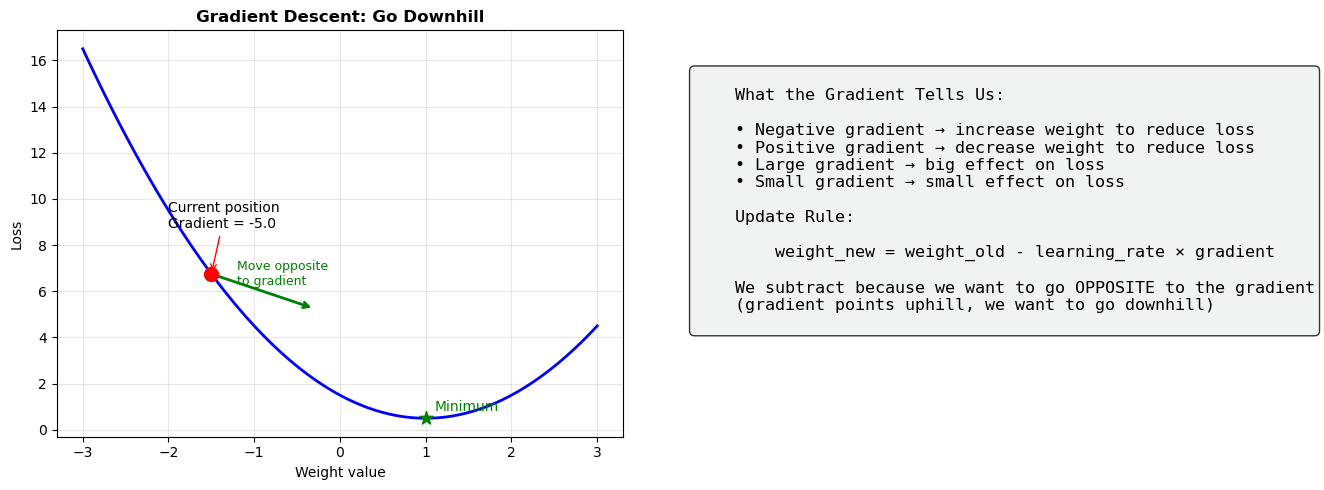

In [26]:
plot_gradient_intuition()

### How Does PyTorch Compute Gradients?

When you call `loss.backward()`, PyTorch:
1. Traces back through all the operations (multiply, add, ReLU, sigmoid, loss)
2. Uses the chain rule to compute how each weight affects the final loss
3. Stores the gradient for each weight

This process is called **backpropagation**. The math involves calculus (chain rule), but you don't need to understand the details to use it effectively.

What matters is the intuition:
- After `loss.backward()`, every weight has a `.grad` attribute
- This gradient tells us: "if you increase this weight by a tiny amount, the loss will change by approximately `gradient × that tiny amount`"
- Negative gradient = increasing weight reduces loss (good!)
- Positive gradient = increasing weight increases loss (bad, so decrease it)

In [27]:
# Let's see actual gradients from PyTorch
torch.manual_seed(42)

# Create a model
simple_model = nn.Sequential(
    nn.Linear(4, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
    nn.Sigmoid()
)

# Forward pass
predictions = simple_model(X_train_t)
loss = nn.BCELoss()(predictions, y_train_t)

print(f"Loss before backward: {loss.item():.4f}")
print(f"Gradients before backward: {simple_model[0].weight.grad}")

# Backward pass - computes all gradients
loss.backward()

print(f"\nAfter loss.backward():")
print(f"Gradients are now computed!")

Loss before backward: 0.7891
Gradients before backward: None

After loss.backward():
Gradients are now computed!


In [28]:
# Look at the gradients for the first layer weights
layer1_gradients = simple_model[0].weight.grad.numpy()

print("Layer 1 Weight Gradients:")
print("="*55)
print(f"Shape: {layer1_gradients.shape} (8 neurons × 4 features)")
print()
print("Sample gradients (first 3 neurons):")
for neuron_idx in range(3):
    grads = layer1_gradients[neuron_idx]
    print(f"\n  Neuron {neuron_idx}:")
    for feat_idx, (feat, grad) in enumerate(zip(features, grads)):
        direction = "decrease" if grad > 0 else "increase"
        print(f"    {feat:8s}: grad = {grad:+.4f} → should {direction} this weight")

Layer 1 Weight Gradients:
Shape: (8, 4) (8 neurons × 4 features)

Sample gradients (first 3 neurons):

  Neuron 0:
    Pclass  : grad = +0.0155 → should decrease this weight
    Sex     : grad = +0.0189 → should decrease this weight
    Age     : grad = +0.0036 → should decrease this weight
    Fare    : grad = -0.0140 → should increase this weight

  Neuron 1:
    Pclass  : grad = -0.0113 → should increase this weight
    Sex     : grad = -0.0168 → should increase this weight
    Age     : grad = +0.0032 → should decrease this weight
    Fare    : grad = +0.0105 → should decrease this weight

  Neuron 2:
    Pclass  : grad = +0.0148 → should decrease this weight
    Sex     : grad = +0.0119 → should decrease this weight
    Age     : grad = +0.0081 → should decrease this weight
    Fare    : grad = -0.0094 → should increase this weight


## Part 6: Weight Update — Taking a Step Downhill

Now comes the crucial step: **using gradients to improve weights**.

Imagine you're lost on a hill in complete darkness. You can't see the bottom, but you can feel the slope under your feet. The smart strategy: take a step in the direction that goes downhill.

That's gradient descent. The gradient tells us which direction is "downhill" in the loss landscape.

$$\text{weight}_{\text{new}} = \text{weight}_{\text{old}} - \text{learning\_rate} \times \text{gradient}$$

**Why does this reduce the loss?**
- The gradient points toward *increasing* loss
- We move in the *opposite* direction (hence the minus sign)
- After the update, the same input will produce a slightly better prediction
- Repeat thousands of times → weights converge to good values

In [29]:
# Let's do a manual weight update
learning_rate = 0.01

# Get current weight and gradient for one specific weight
weight_before = simple_model[0].weight[0, 0].item()  # Neuron 0, Feature 0 (Pclass)
gradient = simple_model[0].weight.grad[0, 0].item()

# Compute the update
update = learning_rate * gradient
weight_after = weight_before - update

print("Manual Weight Update Example")
print("="*50)
print(f"Weight (Neuron 0 ← Pclass):")
print(f"  Before:          {weight_before:+.6f}")
print(f"  Gradient:        {gradient:+.6f}")
print(f"  Learning rate:   {learning_rate}")
print(f"  Update:          {update:+.6f}")
print(f"  After:           {weight_after:+.6f}")
print(f"\nFormula: new = old - lr × gradient")
print(f"         {weight_after:.6f} = {weight_before:.6f} - {learning_rate} × {gradient:.6f}")

Manual Weight Update Example
Weight (Neuron 0 ← Pclass):
  Before:          +0.382269
  Gradient:        +0.015467
  Learning rate:   0.01
  Update:          +0.000155
  After:           +0.382115

Formula: new = old - lr × gradient
         0.382115 = 0.382269 - 0.01 × 0.015467


## Part 7: The Complete Training Loop

We've seen each piece individually:
- **Forward pass**: data flows through layers to produce predictions
- **Loss**: measures how wrong those predictions are
- **Backward pass**: computes gradients (blame for each weight)
- **Weight update**: adjusts weights to reduce loss

Now let's watch them work together. We'll train the network and see the loss decrease in real-time.

In [30]:
# Training from scratch (conceptual version)
torch.manual_seed(42)

# Initialize model
training_model = nn.Sequential(
    nn.Linear(4, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
    nn.Sigmoid()
)

# Hyperparameters
learning_rate = 0.1
n_epochs = 200

# Track progress
losses = []
accuracies = []

print("Training Loop (Manual SGD)")
print("="*55)

for epoch in range(n_epochs):
    # ===== FORWARD PASS =====
    predictions = training_model(X_train_t)
    
    # ===== COMPUTE LOSS =====
    loss = nn.BCELoss()(predictions, y_train_t)
    losses.append(loss.item())
    
    # ===== BACKWARD PASS =====
    # First, clear old gradients (they accumulate by default)
    for param in training_model.parameters():
        if param.grad is not None:
            param.grad.zero_()
    
    # Compute new gradients
    loss.backward()
    
    # ===== UPDATE WEIGHTS =====
    # Manual SGD: weight = weight - learning_rate * gradient
    with torch.no_grad():  # Don't track these operations
        for param in training_model.parameters():
            param -= learning_rate * param.grad
    
    # Track accuracy
    with torch.no_grad():
        pred_classes = (predictions >= 0.5).float()
        accuracy = (pred_classes == y_train_t).float().mean().item()
        accuracies.append(accuracy)
    
    # Print progress
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:3d}: Loss = {loss.item():.4f}, Accuracy = {accuracy:.1%}")

print("\nTraining complete!")

Training Loop (Manual SGD)


Epoch  50: Loss = 0.5652, Accuracy = 80.9%


Epoch 100: Loss = 0.4531, Accuracy = 81.1%


Epoch 150: Loss = 0.4299, Accuracy = 80.7%
Epoch 200: Loss = 0.4238, Accuracy = 81.1%

Training complete!


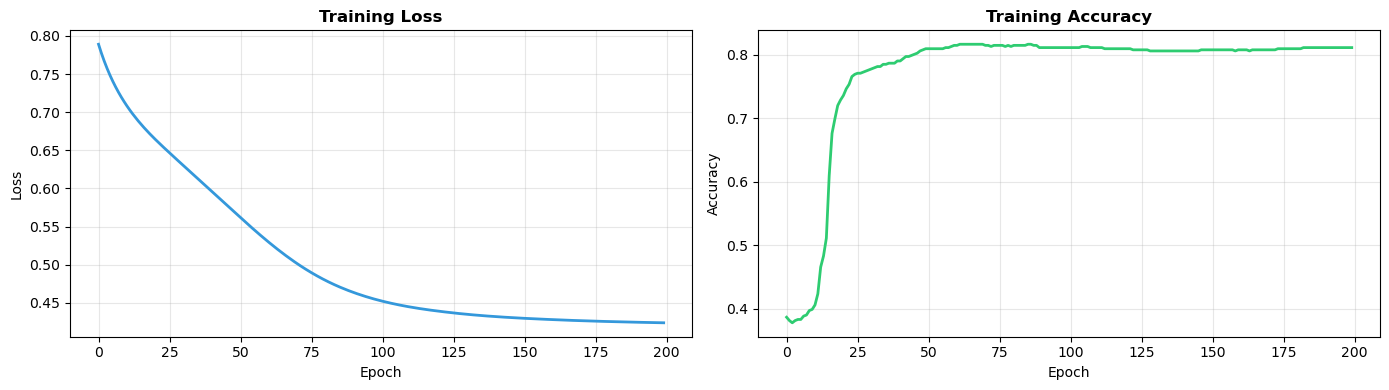

In [31]:
plot_training_progress(losses, accuracies)

In [32]:
# Evaluate on validation set
training_model.eval()
with torch.no_grad():
    val_predictions = training_model(X_val_t)
    val_pred_classes = (val_predictions >= 0.5).float()
    val_accuracy = (val_pred_classes == y_val_t).float().mean().item()
    val_loss = nn.BCELoss()(val_predictions, y_val_t).item()

print("Final Results")
print("="*40)
print(f"Training Loss:      {losses[-1]:.4f}")
print(f"Training Accuracy:  {accuracies[-1]:.1%}")
print(f"Validation Loss:    {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.1%}")

Final Results
Training Loss:      0.4238
Training Accuracy:  81.1%
Validation Loss:    0.5012
Validation Accuracy: 72.7%


### What Did the Network Learn?

Training changed the weights from random noise into meaningful patterns. Let's see what the network discovered about survival:

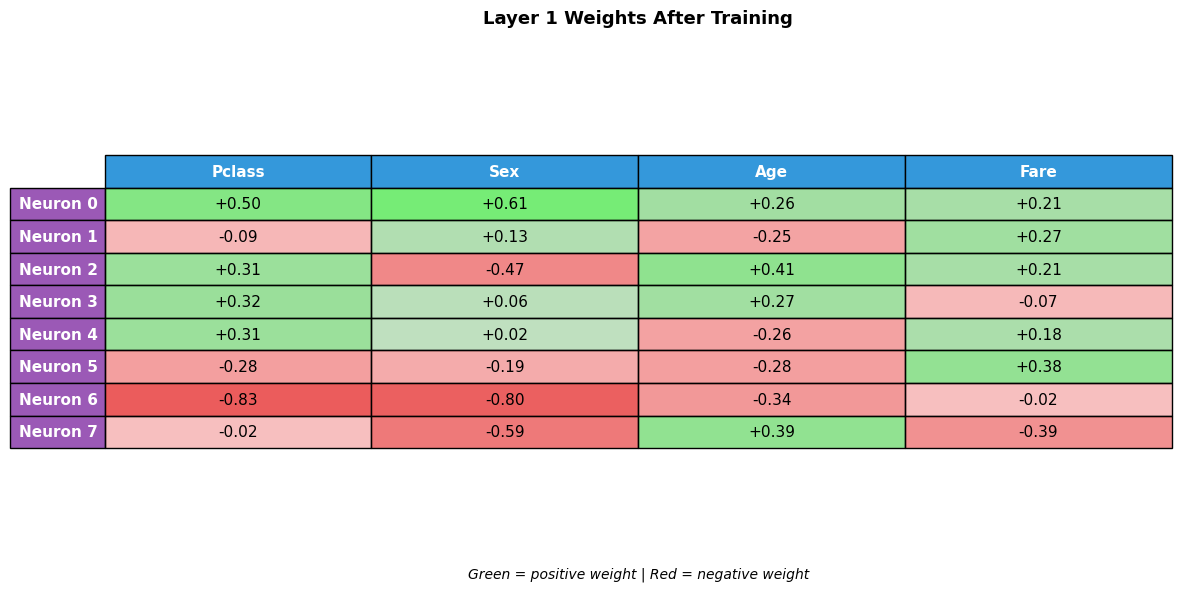


Observations:
- Some neurons have strong negative weights for Sex (being male hurts survival)
- Neurons develop different 'recipes' for detecting survival patterns


In [33]:
# Get trained weights
W1_trained = training_model[0].weight.detach().numpy()

# Show as table
show_weight_table(
    W1_trained,
    feature_labels=['Pclass', 'Sex', 'Age', 'Fare'],
    neuron_labels=[f'Neuron {i}' for i in range(8)],
    title='Layer 1 Weights After Training'
)

print("\nObservations:")
print("- Some neurons have strong negative weights for Sex (being male hurts survival)")
print("- Neurons develop different 'recipes' for detecting survival patterns")

### The Learning Rate: A Critical Hyperparameter

The learning rate controls how big each weight update is. It's one of the most important settings in neural network training.

**What happens with different learning rates:**
- **Too small**: Training is very slow, might get stuck
- **Too large**: Training becomes unstable, loss explodes
- **Just right**: Steady decrease in loss

Let's see this in action:

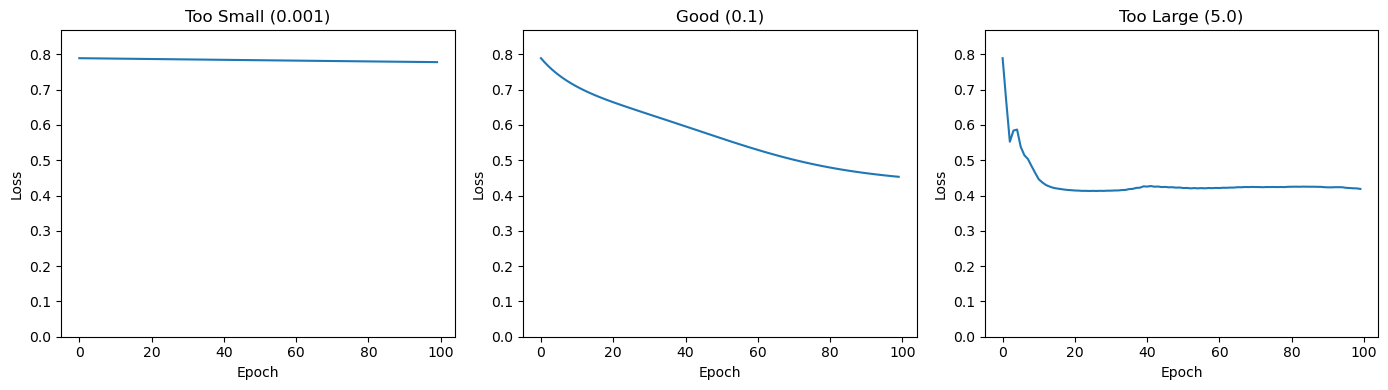

Notice:
- lr=0.001: Loss barely moves after 100 epochs
- lr=0.1:   Loss decreases steadily and converges
- lr=5.0:   Loss jumps around wildly or explodes


In [34]:
# Compare different learning rates
def train_with_lr(lr, n_epochs=100):
    torch.manual_seed(42)
    model = nn.Sequential(nn.Linear(4, 8), nn.ReLU(), nn.Linear(8, 1), nn.Sigmoid())
    losses = []
    for epoch in range(n_epochs):
        pred = model(X_train_t)
        loss = nn.BCELoss()(pred, y_train_t)
        losses.append(loss.item())
        model.zero_grad()
        loss.backward()
        with torch.no_grad():
            for param in model.parameters():
                param -= lr * param.grad
    return losses

# Try three learning rates
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, lr, title in zip(axes, [0.001, 0.1, 5.0], ['Too Small (0.001)', 'Good (0.1)', 'Too Large (5.0)']):
    losses = train_with_lr(lr)
    ax.plot(losses)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(title)
    ax.set_ylim(0, min(3, max(losses[:50]) * 1.1))

plt.tight_layout()
plt.show()

print("Notice:")
print("- lr=0.001: Loss barely moves after 100 epochs")
print("- lr=0.1:   Loss decreases steadily and converges")
print("- lr=5.0:   Loss jumps around wildly or explodes")

### Overfitting: When the Network Memorizes Instead of Learns

Neural networks have many parameters — our small network has 49, but real networks have millions. With enough parameters, a network can **memorize** the training data instead of learning general patterns.

**The warning signs:**
- Training loss keeps decreasing
- Validation loss starts increasing
- Gap between training and validation accuracy grows

Let's train for too long and watch this happen:

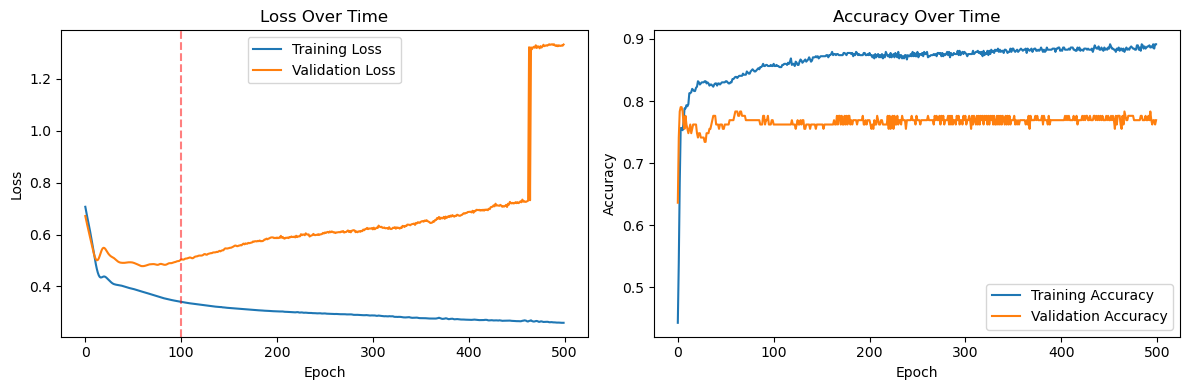

At epoch 100:  Train Acc = 86.0%, Val Acc = 76.2%
At epoch 500:  Train Acc = 89.1%, Val Acc = 76.9%

The network got better at the training data but WORSE at new data!


In [35]:
# Train for many epochs to show overfitting
torch.manual_seed(42)
model_overfit = nn.Sequential(nn.Linear(4, 32), nn.ReLU(), nn.Linear(32, 16), nn.ReLU(), nn.Linear(16, 1), nn.Sigmoid())
optimizer = optim.Adam(model_overfit.parameters(), lr=0.01)

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(500):
    # Training
    model_overfit.train()
    pred = model_overfit(X_train_t)
    loss = nn.BCELoss()(pred, y_train_t)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Track metrics
    with torch.no_grad():
        model_overfit.eval()
        train_losses.append(loss.item())
        train_accs.append(((pred >= 0.5) == y_train_t).float().mean().item())
        
        val_pred = model_overfit(X_val_t)
        val_losses.append(nn.BCELoss()(val_pred, y_val_t).item())
        val_accs.append(((val_pred >= 0.5) == y_val_t).float().mean().item())

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Training Loss')
ax1.plot(val_losses, label='Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Over Time')
ax1.legend()
ax1.axvline(x=100, color='red', linestyle='--', alpha=0.5, label='Should stop here')

ax2.plot(train_accs, label='Training Accuracy')
ax2.plot(val_accs, label='Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Over Time')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"At epoch 100:  Train Acc = {train_accs[100]:.1%}, Val Acc = {val_accs[100]:.1%}")
print(f"At epoch 500:  Train Acc = {train_accs[-1]:.1%}, Val Acc = {val_accs[-1]:.1%}")
print("\nThe network got better at the training data but WORSE at new data!")

**How to combat overfitting:**

1. **Early stopping** — Stop training when validation loss starts increasing
2. **Less capacity** — Use fewer layers or neurons
3. **Regularization** — Techniques like dropout (randomly turning off neurons during training)
4. **More data** — Harder to memorize a larger dataset

For now, the key insight is: **always monitor validation loss, not just training loss.**

### Hyperparameters: Choices You Make Before Training

Unlike weights (which the network learns), **hyperparameters** are choices you make:

| Hyperparameter | What It Controls | Typical Starting Point |
|----------------|------------------|----------------------|
| Learning rate | Size of weight updates | 0.001 - 0.01 for Adam |
| # of layers | Network depth | 1-3 for tabular data |
| # of neurons | Layer width | 8-128 per layer |
| Batch size | Samples per update | 32-128 |
| # of epochs | Training duration | Until validation loss stops improving |

**Rules of thumb for tabular data:**
- Start simple (1-2 hidden layers, 16-64 neurons)
- More parameters = more capacity to learn, but also more overfitting risk
- If underfitting (low train accuracy): increase capacity
- If overfitting (train >> val accuracy): decrease capacity or add regularization

There's no perfect formula — hyperparameter tuning is part of the ML workflow, which we'll cover more in the next lesson.

## Part 8: Optimizers — Smarter Ways to Update

In our training loop, we manually updated every parameter:

```python
for param in model.parameters():
    param.data -= learning_rate * param.grad
```

This is **Stochastic Gradient Descent (SGD)** — it works, but it's tedious to write and has limitations.

**Adam** is the modern default. It:
- Handles the parameter loop automatically
- Adapts the learning rate for each weight individually
- Uses momentum (remembers past gradients for smoother updates)
- Generally converges faster and more reliably

When you write `optimizer.step()`, all that complexity is handled for you.

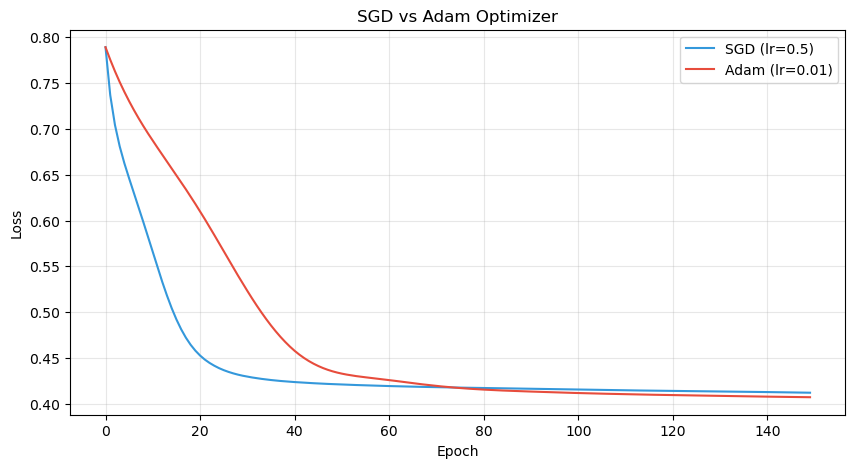

Final loss - SGD:  0.4121
Final loss - Adam: 0.4072

Adam typically converges faster, even with a lower learning rate.


In [36]:
# Compare SGD vs Adam
def train_with_optimizer(optimizer_name, lr, n_epochs=150):
    """Train a model and return the loss history."""
    torch.manual_seed(42)
    model = nn.Sequential(
        nn.Linear(4, 8),
        nn.ReLU(),
        nn.Linear(8, 1),
        nn.Sigmoid()
    )
    
    if optimizer_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=lr)
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr)
    
    losses = []
    for epoch in range(n_epochs):
        predictions = model(X_train_t)
        loss = nn.BCELoss()(predictions, y_train_t)
        losses.append(loss.item())
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    return losses

# Train with both optimizers
sgd_losses = train_with_optimizer('SGD', lr=0.5)
adam_losses = train_with_optimizer('Adam', lr=0.01)

# Plot comparison
plt.figure(figsize=(10, 5))
plt.plot(sgd_losses, label='SGD (lr=0.5)', color='#3498db')
plt.plot(adam_losses, label='Adam (lr=0.01)', color='#e74c3c')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('SGD vs Adam Optimizer')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Final loss - SGD:  {sgd_losses[-1]:.4f}")
print(f"Final loss - Adam: {adam_losses[-1]:.4f}")
print(f"\nAdam typically converges faster, even with a lower learning rate.")

### When to Use Which Optimizer?

**Adam** is a safe default for most problems. It's what you'll use 90% of the time.

**SGD** (with momentum) is sometimes preferred for:
- Very large-scale training (where Adam's memory overhead matters)
- When you need very precise control over learning rate schedules
- Some researchers find it generalizes slightly better on certain tasks

For now, stick with Adam. You can experiment with SGD later when you have more experience.

### Scaling Up: Epochs and Batches

Our training loop processed **all passengers at once** each iteration. This works for small datasets like Titanic (712 samples), but what about millions of samples?

In practice, training uses **batches**:

```python
for epoch in range(n_epochs):           # Repeat many times
    for batch in data_loader:           # Process chunks of data
        predictions = model(batch)
        loss = loss_fn(predictions, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
```

- **Batch**: A small subset (e.g., 32 or 64 samples) processed together
- **Epoch**: One complete pass through all batches

**Why batches?** Less memory, more frequent updates, and the noise can actually help training. We'll use this properly in the next lesson.

## Summary

Let's see the complete picture — everything that happens during one training iteration:

In [37]:
print("""
THE TRAINING LOOP
═══════════════════════════════════════════════════════════════

for each epoch:
    │
    ▼
┌─────────────────────────────────────────────────────────────┐
│  1. FORWARD PASS                                            │
│     Input → [Linear → ReLU] → [Linear → Sigmoid] → Output   │
│     "What does the network predict?"                        │
└─────────────────────────────────────────────────────────────┘
    │
    ▼
┌─────────────────────────────────────────────────────────────┐
│  2. COMPUTE LOSS                                            │
│     Loss = cross_entropy(predictions, targets)              │
│     "How wrong is the network?"                             │
└─────────────────────────────────────────────────────────────┘
    │
    ▼
┌─────────────────────────────────────────────────────────────┐
│  3. BACKWARD PASS                                           │
│     loss.backward() → computes all gradients                │
│     "How much did each weight contribute to the error?"     │
└─────────────────────────────────────────────────────────────┘
    │
    ▼
┌─────────────────────────────────────────────────────────────┐
│  4. UPDATE WEIGHTS                                          │
│     weight = weight - learning_rate × gradient              │
│     "Adjust weights to reduce error next time"              │
└─────────────────────────────────────────────────────────────┘
    │
    └──────────────────────────────────────────────────────────┐
                                                               │
    repeat until loss is low enough                            │
    ◄──────────────────────────────────────────────────────────┘

═══════════════════════════════════════════════════════════════
""")


THE TRAINING LOOP
═══════════════════════════════════════════════════════════════

for each epoch:
    │
    ▼
┌─────────────────────────────────────────────────────────────┐
│  1. FORWARD PASS                                            │
│     Input → [Linear → ReLU] → [Linear → Sigmoid] → Output   │
│     "What does the network predict?"                        │
└─────────────────────────────────────────────────────────────┘
    │
    ▼
┌─────────────────────────────────────────────────────────────┐
│  2. COMPUTE LOSS                                            │
│     Loss = cross_entropy(predictions, targets)              │
│     "How wrong is the network?"                             │
└─────────────────────────────────────────────────────────────┘
    │
    ▼
┌─────────────────────────────────────────────────────────────┐
│  3. BACKWARD PASS                                           │
│     loss.backward() → computes all gradients                │
│     "How much did each weight 

### Key Takeaways

1. **Weights** are the numbers the network learns. They start random and get adjusted during training.

2. **Forward pass** is just matrix multiplication + non-linearities. Data flows through layers, getting transformed at each step.

3. **Loss** measures how wrong the predictions are. We want to minimize it.

4. **Gradients** tell us how to adjust each weight. They're computed automatically by PyTorch via backpropagation.

5. **Weight update** moves weights in the direction that reduces loss: `weight -= lr * gradient`

6. **Optimizers** like Adam make this process smarter and faster.

### What We Didn't Cover (And That's OK)

We skipped the calculus of backpropagation (chain rule, partial derivatives). You don't need it to use neural networks effectively — PyTorch handles it automatically.

If you're curious, there are great resources that explain the math. But for practical ML, understanding the *what* and *why* matters more than the detailed *how*.

## What's Next?

You now understand what happens inside a neural network:
- Forward pass (matrix multiplication + activations)
- Loss calculation (measuring prediction error)  
- Backward pass (computing gradients)
- Weight updates (gradient descent)
- Optimizers (Adam vs SGD)

The next lesson covers the **full tabular ML pipeline**: handling messy data, proper evaluation metrics, and building end-to-end workflows.

After that, we'll explore **tree-based models** (Random Forest, Gradient Boosting) — which often outperform neural networks on tabular data!

<div style="text-align: center; color: #888; font-size: 0.85em; margin-top: 40px; padding-top: 10px; border-top: 1px solid #ddd;">
© 2025 Utvecklarakademin UA Aktiebolag. All rights reserved.<br>
This material is proprietary and may not be reproduced, distributed, or shared without written permission.
</div>